# Fraud Detection on the Elliptic++ Transaction Graph

This notebook builds a **transaction-level fraud detector** from the local Elliptic++ dataset in `data/raw/elliptic++dataset`.

Files used in the baseline model:
- `txs_features.csv`
- `txs_classes.csv`
- `txs_edgelist.csv`

Extra Elliptic++ files are also inspected:
- `TxAddr_edgelist.csv`
- `AddrAddr_edgelist.csv`
- `wallets_features.csv`
- `wallets_classes.csv`

The model is a **GCN on the transaction graph** with a **time-based split** so we do not train on future transaction periods.

This notebook now contains both:
- a baseline transaction-only GCN
- an upgraded GCN with wallet-derived transaction features for comparison


In [50]:
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'elliptic++dataset').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing data/raw/elliptic++dataset')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'elliptic++dataset'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'elliptic_plus_plus'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Device:       {DEVICE}')
print(f'PyTorch:      {torch.__version__}')


Project root: /Users/kuijun/Desktop/spring-2026-spec-proj
Data dir:     /Users/kuijun/Desktop/spring-2026-spec-proj/data/raw/elliptic++dataset
Device:       cpu
PyTorch:      2.4.1


## 1. Load the Elliptic++ tables

`txs_features.csv` in this repo already has column headers, so we load it with the default Pandas behavior.


In [51]:
tx_features_raw = pd.read_csv(DATA_DIR / 'txs_features.csv')
tx_classes_raw = pd.read_csv(DATA_DIR / 'txs_classes.csv')
tx_edges_raw = pd.read_csv(DATA_DIR / 'txs_edgelist.csv')
tx_addr_edges_raw = pd.read_csv(DATA_DIR / 'TxAddr_edgelist.csv')
addr_addr_edges_raw = pd.read_csv(DATA_DIR / 'AddrAddr_edgelist.csv')
wallet_features_raw = pd.read_csv(DATA_DIR / 'wallets_features.csv')
wallet_classes_raw = pd.read_csv(DATA_DIR / 'wallets_classes.csv')

summary = pd.DataFrame(
    [
        ('txs_features.csv', tx_features_raw.shape[0], tx_features_raw.shape[1]),
        ('txs_classes.csv', tx_classes_raw.shape[0], tx_classes_raw.shape[1]),
        ('txs_edgelist.csv', tx_edges_raw.shape[0], tx_edges_raw.shape[1]),
        ('TxAddr_edgelist.csv', tx_addr_edges_raw.shape[0], tx_addr_edges_raw.shape[1]),
        ('AddrAddr_edgelist.csv', addr_addr_edges_raw.shape[0], addr_addr_edges_raw.shape[1]),
        ('wallets_features.csv', wallet_features_raw.shape[0], wallet_features_raw.shape[1]),
        ('wallets_classes.csv', wallet_classes_raw.shape[0], wallet_classes_raw.shape[1]),
    ],
    columns=['file', 'rows', 'columns'],
)
summary


,file,rows,columns
0,txs_features.csv,203769,184
1,txs_classes.csv,203769,2
2,txs_edgelist.csv,234355,2
3,TxAddr_edgelist.csv,837124,2
4,AddrAddr_edgelist.csv,2868964,2
5,wallets_features.csv,1268260,57
6,wallets_classes.csv,822942,2


In [52]:
def clean_columns(columns):
    cleaned = []
    for col in columns:
        col = str(col).strip().replace(' ', '_').replace('-', '_').replace('/', '_')
        col = col.replace('(', '').replace(')', '').replace('__', '_')
        cleaned.append(col)
    return cleaned


LABEL_MAP = {'1': 1, '2': 0, '3': -1, 'unknown': -1, 'illicit': 1, 'licit': 0}

transactions = tx_features_raw.copy()
transactions.columns = clean_columns(transactions.columns)
transactions = transactions.rename(columns={'Time_step': 'time_step'})
transactions['txId'] = pd.to_numeric(transactions['txId'], errors='raise').astype(np.int64)
transactions['time_step'] = pd.to_numeric(transactions['time_step'], errors='raise').astype(np.int64)

feature_columns = [col for col in transactions.columns if col not in ['txId', 'time_step']]
transactions[feature_columns] = transactions[feature_columns].apply(pd.to_numeric, errors='coerce')
transactions[feature_columns] = transactions[feature_columns].fillna(0.0)

labels = tx_classes_raw.copy()
labels['txId'] = pd.to_numeric(labels['txId'], errors='raise').astype(np.int64)
labels['class'] = labels['class'].astype(str)
labels['label'] = labels['class'].map(LABEL_MAP).fillna(-1).astype(np.int64)

transactions = transactions.merge(labels[['txId', 'class', 'label']], on='txId', how='left')
transactions['class'] = transactions['class'].fillna('unknown')
transactions['label'] = transactions['label'].fillna(-1).astype(np.int64)

transaction_edges = tx_edges_raw.copy()
transaction_edges['txId1'] = pd.to_numeric(transaction_edges['txId1'], errors='raise').astype(np.int64)
transaction_edges['txId2'] = pd.to_numeric(transaction_edges['txId2'], errors='raise').astype(np.int64)

print(f'Transactions: {len(transactions):,}')
print(f'Feature columns: {len(feature_columns):,}')
print(f'Transaction edges: {len(transaction_edges):,}')
print(f'Tx-address edges: {len(tx_addr_edges_raw):,}')
print(f'Address-address edges: {len(addr_addr_edges_raw):,}')
print(f'Wallet feature rows: {len(wallet_features_raw):,}')
print(f'Time steps: {transactions["time_step"].min()} to {transactions["time_step"].max()}')
print('Label counts (0=licit, 1=illicit, -1=unknown):')
print(transactions['label'].value_counts(dropna=False).sort_index())


Transactions: 203,769
Feature columns: 182
Transaction edges: 234,355
Tx-address edges: 837,124
Address-address edges: 2,868,964
Wallet feature rows: 1,268,260
Time steps: 1 to 49
Label counts (0=licit, 1=illicit, -1=unknown):
label
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


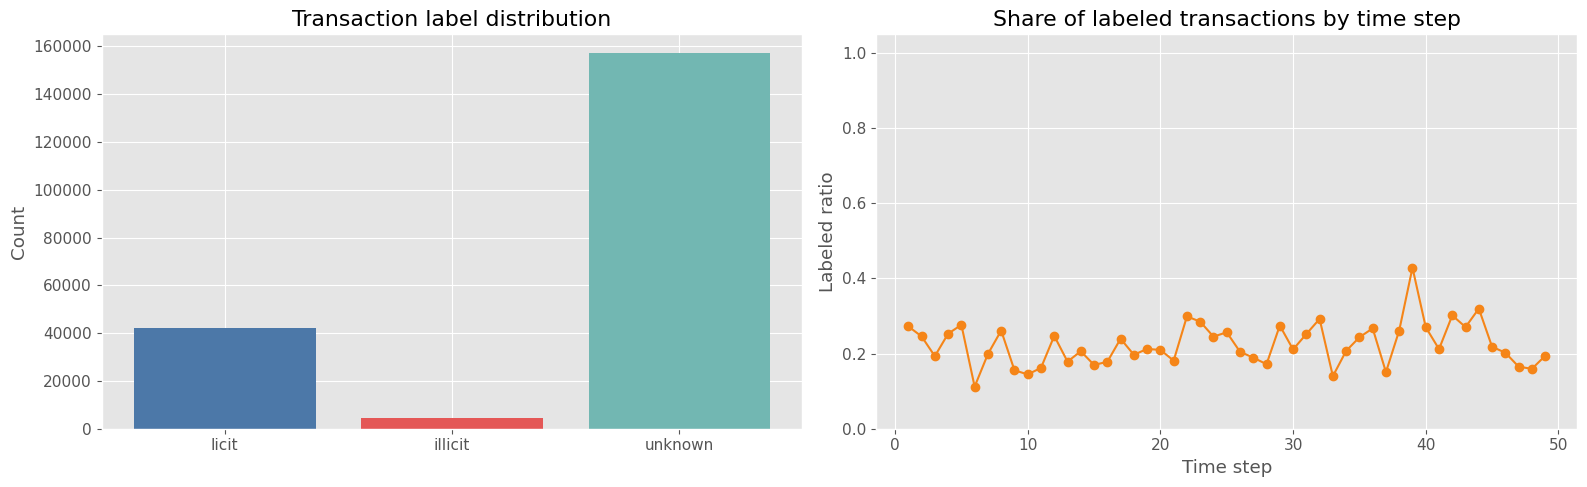

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_counts = (
    transactions['label']
    .map({0: 'licit', 1: 'illicit', -1: 'unknown'})
    .value_counts()
    .reindex(['licit', 'illicit', 'unknown'])
    .fillna(0)
)
axes[0].bar(class_counts.index, class_counts.values, color=['#4c78a8', '#e45756', '#72b7b2'])
axes[0].set_title('Transaction label distribution')
axes[0].set_ylabel('Count')

labeled_ratio_by_step = (
    transactions.assign(is_labeled=transactions['label'].isin([0, 1]))
    .groupby('time_step')[['is_labeled']]
    .mean()
    .rename(columns={'is_labeled': 'labeled_ratio'})
)
axes[1].plot(labeled_ratio_by_step.index, labeled_ratio_by_step['labeled_ratio'], marker='o', color='#f58518')
axes[1].set_title('Share of labeled transactions by time step')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Labeled ratio')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIG_DIR / 'elliptic_pp_dataset_overview.png', dpi=180, bbox_inches='tight')
plt.show()


## 2. Build the transaction graph dataset

This baseline trains on transaction nodes only:
- node features: all numeric columns from `txs_features.csv`
- labels: illicit vs licit from `txs_classes.csv`
- graph edges: `txs_edgelist.csv`

Temporal split:
- train: time steps `1-34`
- validation: time steps `35-39`
- test: time steps `40-49`


In [54]:
TRAIN_STEPS = list(range(1, 35))
VAL_STEPS = list(range(35, 40))
TEST_STEPS = list(range(40, 50))

train_period_mask = transactions['time_step'].isin(TRAIN_STEPS)
val_period_mask = transactions['time_step'].isin(VAL_STEPS)
test_period_mask = transactions['time_step'].isin(TEST_STEPS)
known_label_mask = transactions['label'].isin([0, 1])

scaler = StandardScaler()
scaler.fit(transactions.loc[train_period_mask, feature_columns])
X = scaler.transform(transactions[feature_columns]).astype(np.float32)

y = transactions['label'].to_numpy(dtype=np.int64)

tx_ids = transactions['txId'].to_numpy()
tx_to_idx = {tx_id: idx for idx, tx_id in enumerate(tx_ids)}

src = transaction_edges['txId1'].map(tx_to_idx)
dst = transaction_edges['txId2'].map(tx_to_idx)
valid_edges = src.notna() & dst.notna()
edge_index = torch.tensor(
    np.vstack([
        src.loc[valid_edges].to_numpy(dtype=np.int64),
        dst.loc[valid_edges].to_numpy(dtype=np.int64),
    ]),
    dtype=torch.long,
)
edge_index = to_undirected(edge_index)

data = Data(
    x=torch.tensor(X, dtype=torch.float32),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long),
)

data.train_mask = torch.tensor((train_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
data.val_mask = torch.tensor((val_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
data.test_mask = torch.tensor((test_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)

print(data)
print(f'Train labeled nodes: {int(data.train_mask.sum()):,}')
print(f'Validation labeled nodes: {int(data.val_mask.sum()):,}')
print(f'Test labeled nodes: {int(data.test_mask.sum()):,}')
print(f'Undirected edge count: {data.edge_index.shape[1]:,}')


Data(x=[203769, 182], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Train labeled nodes: 29,894
Validation labeled nodes: 5,486
Test labeled nodes: 11,184
Undirected edge count: 468,710


In [55]:
train_targets = data.y[data.train_mask]
class_counts = torch.bincount(train_targets, minlength=2)
class_weights = (class_counts.sum() / (2.0 * class_counts.clamp_min(1))).to(torch.float32)

pd.DataFrame(
    {
        'split': ['train', 'validation', 'test'],
        'labeled_nodes': [int(data.train_mask.sum()), int(data.val_mask.sum()), int(data.test_mask.sum())],
        'illicit_ratio': [
            float((data.y[data.train_mask] == 1).float().mean()),
            float((data.y[data.val_mask] == 1).float().mean()),
            float((data.y[data.test_mask] == 1).float().mean()),
        ],
    }
)


,split,labeled_nodes,illicit_ratio
0,train,29894,0.115809
1,validation,5486,0.081480
2,test,11184,0.056867


## 3. Train a GCN baseline


In [56]:
class FraudGCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int = 128, dropout: float = 0.35):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, 2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


def evaluate_split(model, data, mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probabilities = torch.softmax(logits[mask], dim=1)[:, 1].cpu().numpy()
        predictions = logits[mask].argmax(dim=1).cpu().numpy()
        labels = data.y[mask].cpu().numpy()

    metrics = {
        'f1': f1_score(labels, predictions, zero_division=0),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'roc_auc': roc_auc_score(labels, probabilities) if len(np.unique(labels)) > 1 else np.nan,
    }
    return metrics, labels, predictions, probabilities


In [57]:
data = data.to(DEVICE)
model = FraudGCN(in_channels=data.num_node_features, hidden_channels=128, dropout=0.35).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

EPOCHS = 60
PATIENCE = 10

history = []
best_val_f1 = -1.0
best_epoch = -1
best_state = None
patience_counter = 0
model_path = MODEL_DIR / 'gcn_elliptic_plus_plus_best.pt'

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    train_metrics, _, _, _ = evaluate_split(model, data, data.train_mask)
    val_metrics, _, _, _ = evaluate_split(model, data, data.val_mask)

    history.append(
        {
            'epoch': epoch,
            'loss': float(loss.item()),
            'train_f1': train_metrics['f1'],
            'val_f1': val_metrics['f1'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_roc_auc': val_metrics['roc_auc'],
        }
    )

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | loss={loss.item():.4f} | "
            f"train_f1={train_metrics['f1']:.4f} | val_f1={val_metrics['f1']:.4f} | "
            f"val_auc={val_metrics['roc_auc']:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch})')
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()


Epoch 001 | loss=0.8550 | train_f1=0.2077 | val_f1=0.1509 | val_auc=0.2672
Epoch 005 | loss=0.6196 | train_f1=0.5115 | val_f1=0.3416 | val_auc=0.8200
Epoch 010 | loss=0.5298 | train_f1=0.5696 | val_f1=0.3745 | val_auc=0.8497
Epoch 015 | loss=0.4611 | train_f1=0.5638 | val_f1=0.3291 | val_auc=0.8548
Early stopping at epoch 19 (best epoch: 9)


,epoch,loss,train_f1,val_f1,val_precision,val_recall,val_roc_auc
14,15,0.461149,0.563829,0.329125,0.202696,0.874720,0.854775
15,16,0.449600,0.561332,0.313167,0.190202,0.885906,0.854326
16,17,0.438749,0.557415,0.302825,0.182065,0.899329,0.853664
17,18,0.426737,0.551869,0.296972,0.177419,0.910515,0.852889
18,19,0.416645,0.547642,0.291103,0.173085,0.914989,0.852100


## 4. Evaluate the best model


In [58]:
val_metrics, val_labels, val_preds, val_probs = evaluate_split(model, data, data.val_mask)
test_metrics, test_labels, test_preds, test_probs = evaluate_split(model, data, data.test_mask)

metrics_table = pd.DataFrame(
    [
        {'split': 'validation', **val_metrics},
        {'split': 'test', **test_metrics},
    ]
)
metrics_table


,split,f1,precision,recall,roc_auc
0,validation,0.374843,0.260717,0.666667,0.846991
1,test,0.214733,0.132499,0.566038,0.777169


In [59]:
print(f'Best epoch: {best_epoch}')
print(f'Model saved to: {model_path}')
print('\nTest classification report')
print(classification_report(test_labels, test_preds, target_names=['licit', 'illicit'], zero_division=0))


Best epoch: 9
Model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/gcn_elliptic_plus_plus_best.pt

Test classification report
              precision    recall  f1-score   support

       licit       0.97      0.78      0.86     10548
     illicit       0.13      0.57      0.21       636

    accuracy                           0.76     11184
   macro avg       0.55      0.67      0.54     11184
weighted avg       0.92      0.76      0.82     11184



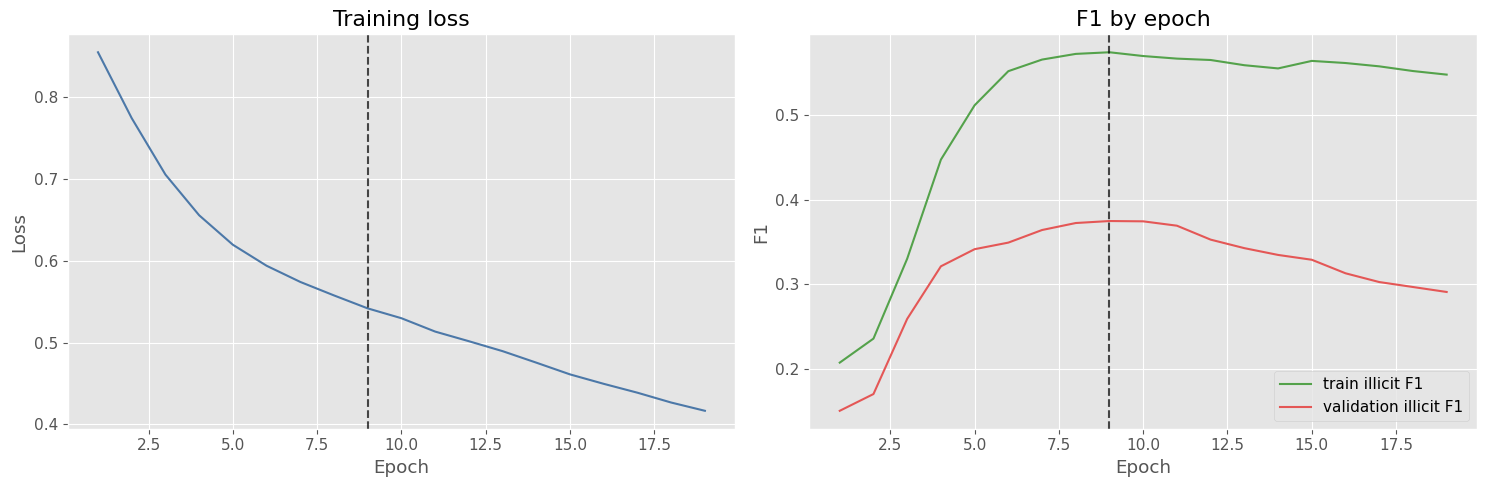

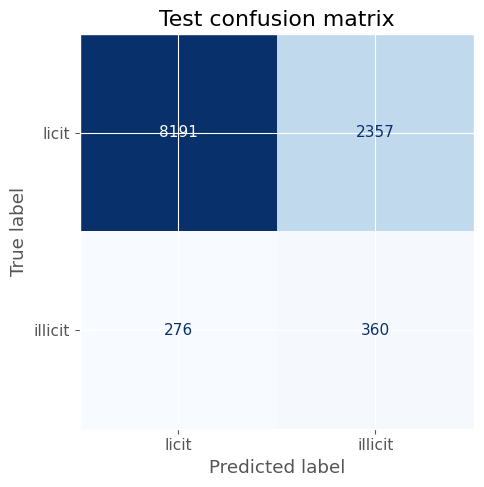

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_df['epoch'], history_df['loss'], color='#4c78a8')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].axvline(best_epoch, color='black', linestyle='--', alpha=0.7)

axes[1].plot(history_df['epoch'], history_df['train_f1'], label='train illicit F1', color='#54a24b')
axes[1].plot(history_df['epoch'], history_df['val_f1'], label='validation illicit F1', color='#e45756')
axes[1].axvline(best_epoch, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('F1 by epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'gcn_elliptic_pp_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(test_labels, test_preds),
    display_labels=['licit', 'illicit'],
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Test confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gcn_elliptic_pp_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()


## 5. Elliptic++ extension path

The remaining files in `data/raw/elliptic++dataset` support a more advanced heterogeneous graph with transaction and wallet nodes:
- `TxAddr_edgelist.csv`
- `AddrAddr_edgelist.csv`
- `wallets_features.csv`
- `wallets_classes.csv`

That is a good next step, but it needs careful time-aware feature engineering so wallet snapshots from the future do not leak into earlier predictions.


## 6. Upgrade: wallet-aware transaction features

The first upgrade only used a hand-picked subset of wallet features. This version uses **all numeric wallet features** from `wallets_features.csv` and also adds **address-graph structural features** derived from `AddrAddr_edgelist.csv`.

For each transaction, we aggregate the linked output-address information into transaction-level features using:
- same-step wallet snapshots from `wallets_features.csv`
- transaction-output address links from `TxAddr_edgelist.csv`
- structural degree features from `AddrAddr_edgelist.csv`

We still avoid label leakage by not using `wallets_classes.csv` as a model input.


In [61]:
wallet_features_enhanced = wallet_features_raw.copy()
wallet_features_enhanced.columns = clean_columns(wallet_features_enhanced.columns)
wallet_features_enhanced = wallet_features_enhanced.rename(columns={'Time_step': 'time_step'})
wallet_features_enhanced['time_step'] = pd.to_numeric(wallet_features_enhanced['time_step'], errors='raise').astype(np.int64)

wallet_numeric_columns = [col for col in wallet_features_enhanced.columns if col not in ['address', 'time_step']]
wallet_features_enhanced[wallet_numeric_columns] = wallet_features_enhanced[wallet_numeric_columns].apply(pd.to_numeric, errors='coerce')
wallet_features_enhanced[wallet_numeric_columns] = wallet_features_enhanced[wallet_numeric_columns].fillna(0.0)

wallet_snapshot_features = (
    wallet_features_enhanced
    .groupby(['address', 'time_step'], as_index=False)[wallet_numeric_columns]
    .mean()
)

addr_graph_edges = addr_addr_edges_raw.rename(
    columns={'input_address': 'src_address', 'output_address': 'dst_address'}
)
addr_out_degree = addr_graph_edges.groupby('src_address').size().rename('addr_out_degree')
addr_in_degree = addr_graph_edges.groupby('dst_address').size().rename('addr_in_degree')
addr_self_loops = (
    addr_graph_edges.loc[addr_graph_edges['src_address'] == addr_graph_edges['dst_address']]
    .groupby('src_address')
    .size()
    .rename('addr_self_loop_count')
)
address_graph_features = (
    pd.concat([addr_out_degree, addr_in_degree, addr_self_loops], axis=1)
    .fillna(0.0)
    .reset_index()
    .rename(columns={'index': 'address', 'src_address': 'address'})
)
address_graph_features['addr_total_degree'] = (
    address_graph_features['addr_out_degree'] + address_graph_features['addr_in_degree']
)
address_graph_feature_columns = [
    'addr_out_degree',
    'addr_in_degree',
    'addr_self_loop_count',
    'addr_total_degree',
]

transaction_address_time = (
    tx_addr_edges_raw
    .rename(columns={'output_address': 'address'})
    .merge(transactions[['txId', 'time_step']], on='txId', how='inner')
    .merge(wallet_snapshot_features[['address', 'time_step'] + wallet_numeric_columns], on=['address', 'time_step'], how='left')
    .merge(address_graph_features[['address'] + address_graph_feature_columns], on='address', how='left')
)
transaction_address_time['wallet_feature_match'] = (
    transaction_address_time[wallet_numeric_columns].notna().any(axis=1).astype(int)
)
transaction_address_time[address_graph_feature_columns] = transaction_address_time[address_graph_feature_columns].fillna(0.0)

all_address_enrichment_columns = wallet_numeric_columns + address_graph_feature_columns
wallet_feature_aggregates = transaction_address_time.groupby('txId')[all_address_enrichment_columns].agg(['mean', 'max'])
wallet_feature_aggregates.columns = [f'wallet_{name}_{stat}' for name, stat in wallet_feature_aggregates.columns]

wallet_feature_meta = transaction_address_time.groupby('txId').agg(
    linked_output_addresses=('address', 'nunique'),
    matched_wallet_rows=('wallet_feature_match', 'sum'),
)
wallet_feature_meta['wallet_match_ratio'] = (
    wallet_feature_meta['matched_wallet_rows']
    / wallet_feature_meta['linked_output_addresses'].replace(0, np.nan)
)

wallet_transaction_features = (
    wallet_feature_meta
    .join(wallet_feature_aggregates, how='left')
    .fillna(0.0)
    .reset_index()
)

transactions_upgraded = transactions.merge(wallet_transaction_features, on='txId', how='left')
wallet_derived_columns = [
    col for col in transactions_upgraded.columns
    if col.startswith('wallet_') or col in ['linked_output_addresses', 'matched_wallet_rows']
]
transactions_upgraded[wallet_derived_columns] = transactions_upgraded[wallet_derived_columns].fillna(0.0)
upgraded_feature_columns = feature_columns + wallet_derived_columns

print(f'Baseline feature count: {len(feature_columns)}')
print(f'Wallet numeric source features used: {len(wallet_numeric_columns)}')
print(f'Address structural source features used: {len(address_graph_feature_columns)}')
print(f'Derived transaction-level feature count: {len(wallet_derived_columns)}')
print(f'Upgraded feature count: {len(upgraded_feature_columns)}')
print(f'Transactions with wallet feature matches: {(transactions_upgraded["matched_wallet_rows"] > 0).sum():,}')

pd.DataFrame({
    'feature_group': [
        'baseline transaction features',
        'wallet numeric source features',
        'address structural source features',
        'derived transaction-level features',
        'upgraded total',
    ],
    'count': [
        len(feature_columns),
        len(wallet_numeric_columns),
        len(address_graph_feature_columns),
        len(wallet_derived_columns),
        len(upgraded_feature_columns),
    ],
})


Baseline feature count: 182
Wallet numeric source features used: 55
Address structural source features used: 4
Derived transaction-level feature count: 121
Upgraded feature count: 303
Transactions with wallet feature matches: 202,804


,feature_group,count
0,baseline transaction features,182
1,wallet numeric source features,55
2,address structural source features,4
3,derived transaction-level features,121
4,upgraded total,303


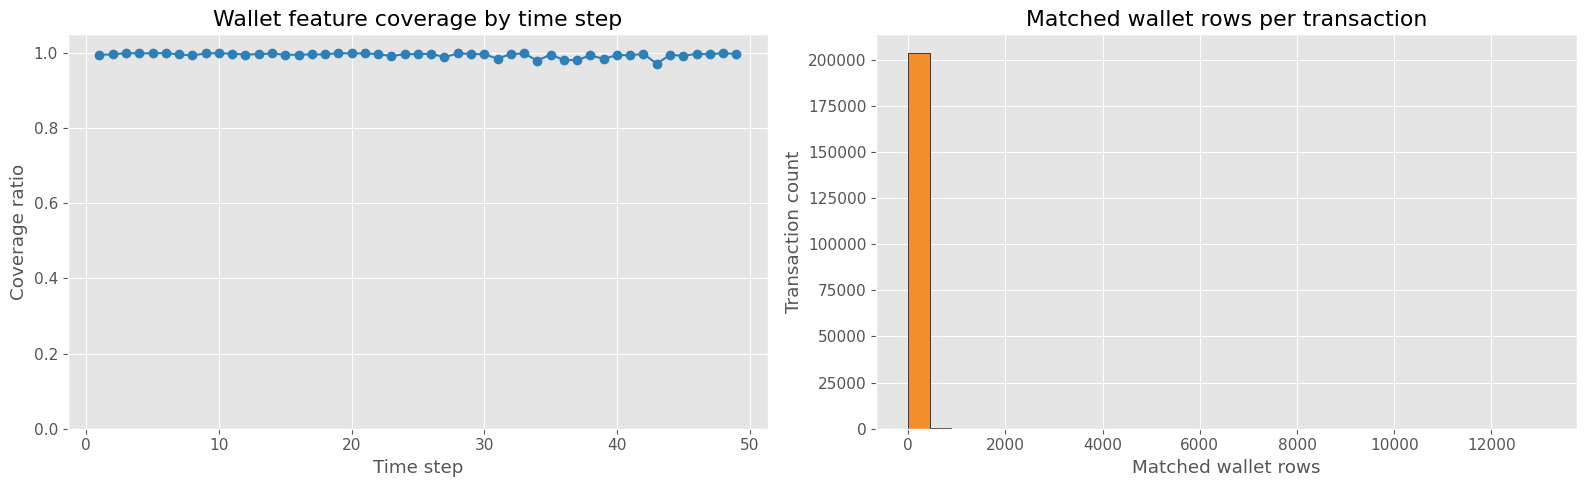

In [62]:
wallet_coverage_by_step = (
    transactions_upgraded.groupby('time_step').agg(
        transactions=('txId', 'size'),
        with_wallet_features=('matched_wallet_rows', lambda s: (s > 0).sum()),
        mean_wallet_match_ratio=('wallet_match_ratio', 'mean'),
    ).reset_index()
)
wallet_coverage_by_step['coverage_ratio'] = (
    wallet_coverage_by_step['with_wallet_features'] / wallet_coverage_by_step['transactions']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(wallet_coverage_by_step['time_step'], wallet_coverage_by_step['coverage_ratio'], marker='o', color='#2c7fb8')
axes[0].set_title('Wallet feature coverage by time step')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Coverage ratio')
axes[0].set_ylim(0, 1.05)

axes[1].hist(transactions_upgraded['matched_wallet_rows'], bins=30, color='#f28e2b', edgecolor='black')
axes[1].set_title('Matched wallet rows per transaction')
axes[1].set_xlabel('Matched wallet rows')
axes[1].set_ylabel('Transaction count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'elliptic_pp_wallet_feature_coverage.png', dpi=180, bbox_inches='tight')
plt.show()


## 7. Train the upgraded model

This model uses the same GCN and the same graph edges, but it replaces the baseline input matrix with the expanded wallet-aware feature matrix.

New artifacts are saved with **different filenames** so you can compare them side by side with the baseline results.


In [63]:
def train_gcn_variant(data_object, model_path, hidden_channels=128, dropout=0.35, lr=1e-3, weight_decay=5e-4, epochs=60, patience=10):
    model_local = FraudGCN(in_channels=data_object.num_node_features, hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)
    data_object = data_object.to(DEVICE)
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr, weight_decay=weight_decay)

    train_targets_local = data_object.y[data_object.train_mask]
    class_counts_local = torch.bincount(train_targets_local, minlength=2)
    class_weights_local = (class_counts_local.sum() / (2.0 * class_counts_local.clamp_min(1))).to(torch.float32)
    criterion_local = nn.CrossEntropyLoss(weight=class_weights_local.to(DEVICE))

    history_local = []
    best_epoch_local = -1
    best_val_f1_local = -1.0
    best_state_local = None
    patience_counter_local = 0

    for epoch in range(1, epochs + 1):
        model_local.train()
        optimizer_local.zero_grad()
        logits_local = model_local(data_object.x, data_object.edge_index)
        loss_local = criterion_local(logits_local[data_object.train_mask], data_object.y[data_object.train_mask])
        loss_local.backward()
        optimizer_local.step()

        train_metrics_local, _, _, _ = evaluate_split(model_local, data_object, data_object.train_mask)
        val_metrics_local, _, _, _ = evaluate_split(model_local, data_object, data_object.val_mask)
        history_local.append({
            'epoch': epoch,
            'loss': float(loss_local.item()),
            'train_f1': train_metrics_local['f1'],
            'val_f1': val_metrics_local['f1'],
            'val_precision': val_metrics_local['precision'],
            'val_recall': val_metrics_local['recall'],
            'val_roc_auc': val_metrics_local['roc_auc'],
        })

        if val_metrics_local['f1'] > best_val_f1_local:
            best_val_f1_local = val_metrics_local['f1']
            best_epoch_local = epoch
            best_state_local = {k: v.detach().cpu().clone() for k, v in model_local.state_dict().items()}
            torch.save(best_state_local, model_path)
            patience_counter_local = 0
        else:
            patience_counter_local += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | loss={loss_local.item():.4f} | "
                f"train_f1={train_metrics_local['f1']:.4f} | val_f1={val_metrics_local['f1']:.4f} | "
                f"val_auc={val_metrics_local['roc_auc']:.4f}"
            )

        if patience_counter_local >= patience:
            print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch_local})')
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    history_local_df = pd.DataFrame(history_local)
    val_metrics_local, val_labels_local, val_preds_local, val_probs_local = evaluate_split(model_local, data_object, data_object.val_mask)
    test_metrics_local, test_labels_local, test_preds_local, test_probs_local = evaluate_split(model_local, data_object, data_object.test_mask)
    return {
        'model': model_local,
        'history': history_local_df,
        'best_epoch': best_epoch_local,
        'model_path': model_path,
        'val_metrics': val_metrics_local,
        'val_labels': val_labels_local,
        'val_preds': val_preds_local,
        'val_probs': val_probs_local,
        'test_metrics': test_metrics_local,
        'test_labels': test_labels_local,
        'test_preds': test_preds_local,
        'test_probs': test_probs_local,
    }

scaler_upgraded = StandardScaler()
scaler_upgraded.fit(transactions_upgraded.loc[train_period_mask, upgraded_feature_columns])
X_upgraded = scaler_upgraded.transform(transactions_upgraded[upgraded_feature_columns]).astype(np.float32)

data_upgraded = Data(
    x=torch.tensor(X_upgraded, dtype=torch.float32),
    edge_index=edge_index.clone(),
    y=torch.tensor(y, dtype=torch.long),
)
data_upgraded.train_mask = torch.tensor((train_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
data_upgraded.val_mask = torch.tensor((val_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
data_upgraded.test_mask = torch.tensor((test_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)

upgrade_result = train_gcn_variant(
    data_upgraded,
    MODEL_DIR / 'gcn_elliptic_plus_plus_wallet_upgrade_best.pt',
)
upgrade_result['history'].tail()


Epoch 001 | loss=0.6849 | train_f1=0.3104 | val_f1=0.2999 | val_auc=0.7727
Epoch 005 | loss=0.5192 | train_f1=0.5620 | val_f1=0.3527 | val_auc=0.8362
Epoch 010 | loss=0.4071 | train_f1=0.5323 | val_f1=0.2987 | val_auc=0.8246
Early stopping at epoch 13 (best epoch: 3)


,epoch,loss,train_f1,val_f1,val_precision,val_recall,val_roc_auc
8,9,0.427684,0.535580,0.302253,0.182887,0.870246,0.826591
9,10,0.407090,0.532273,0.298667,0.179982,0.876957,0.824649
10,11,0.392215,0.531489,0.296745,0.178588,0.876957,0.823021
11,12,0.378535,0.531471,0.297308,0.178995,0.876957,0.821541
12,13,0.365497,0.532324,0.297856,0.179677,0.870246,0.820300


## 8. Baseline vs upgrade comparison


In [64]:
upgraded_history_df = upgrade_result['history']
upgraded_best_epoch = upgrade_result['best_epoch']
upgraded_model_path = upgrade_result['model_path']
upgraded_test_metrics = upgrade_result['test_metrics']
upgraded_test_labels = upgrade_result['test_labels']
upgraded_test_preds = upgrade_result['test_preds']

comparison_df = pd.DataFrame([
    {'model': 'baseline_gcn', **test_metrics},
    {'model': 'wallet_upgrade_gcn', **upgraded_test_metrics},
])
comparison_df['delta_f1_vs_baseline'] = comparison_df['f1'] - comparison_df.loc[0, 'f1']
comparison_df['delta_auc_vs_baseline'] = comparison_df['roc_auc'] - comparison_df.loc[0, 'roc_auc']
comparison_df


,model,f1,precision,recall,roc_auc,delta_f1_vs_baseline,delta_auc_vs_baseline
0,baseline_gcn,0.214733,0.132499,0.566038,0.777169,0.000000,0.000000
1,wallet_upgrade_gcn,0.224496,0.137882,0.603774,0.776892,0.009763,-0.000276


Upgraded best epoch: 3
Upgraded model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/gcn_elliptic_plus_plus_wallet_upgrade_best.pt

Upgraded test classification report
              precision    recall  f1-score   support

       licit       0.97      0.77      0.86     10548
     illicit       0.14      0.60      0.22       636

    accuracy                           0.76     11184
   macro avg       0.55      0.69      0.54     11184
weighted avg       0.92      0.76      0.82     11184



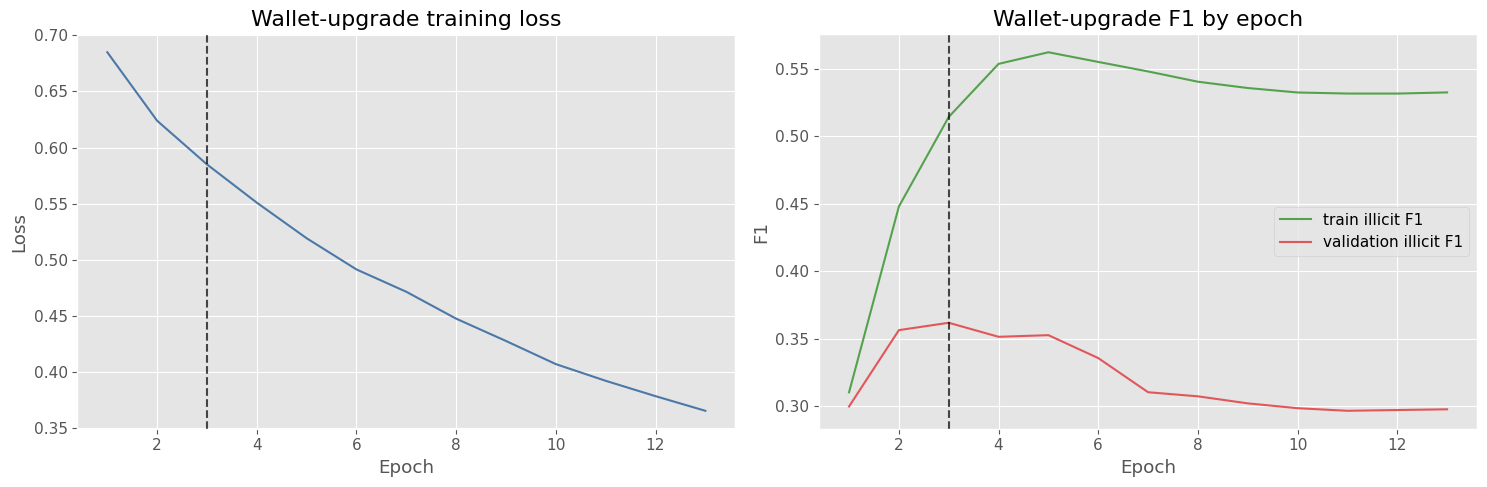

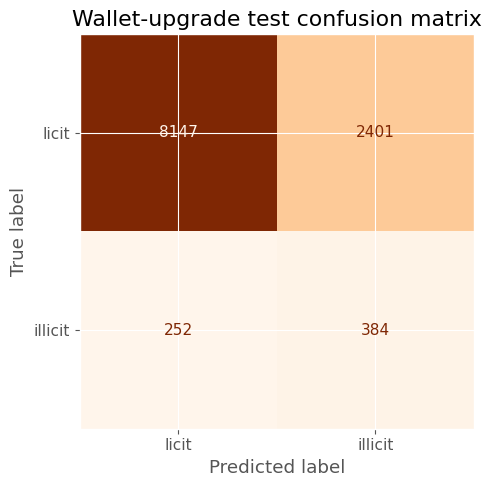

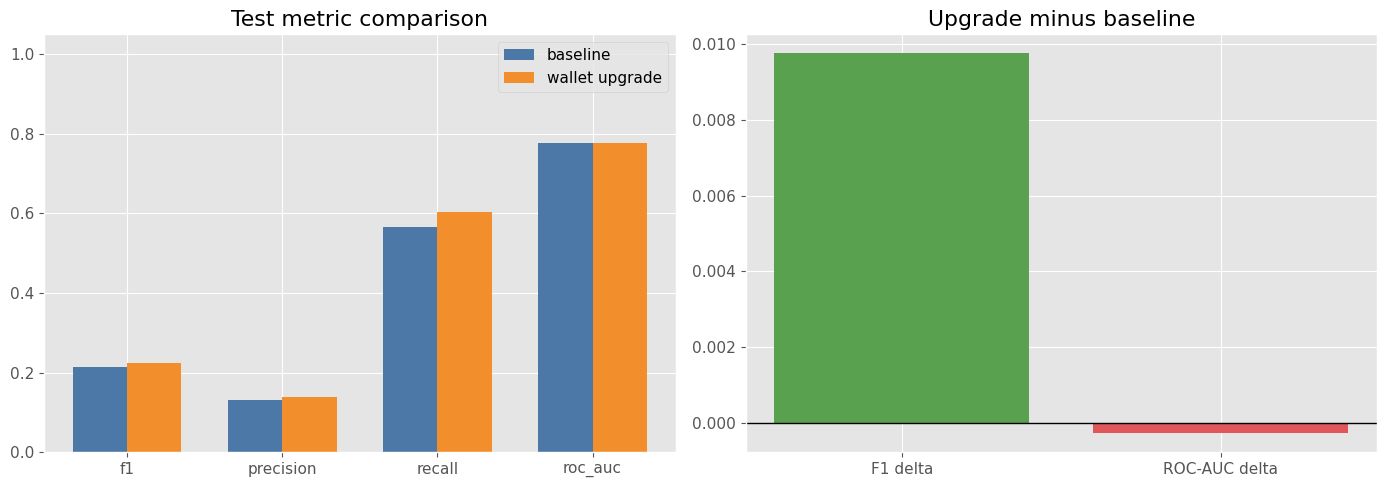

In [65]:
print(f'Upgraded best epoch: {upgraded_best_epoch}')
print(f'Upgraded model saved to: {upgraded_model_path}')
print('\nUpgraded test classification report')
print(classification_report(upgraded_test_labels, upgraded_test_preds, target_names=['licit', 'illicit'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(upgraded_history_df['epoch'], upgraded_history_df['loss'], color='#4c78a8')
axes[0].axvline(upgraded_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Wallet-upgrade training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(upgraded_history_df['epoch'], upgraded_history_df['train_f1'], label='train illicit F1', color='#54a24b')
axes[1].plot(upgraded_history_df['epoch'], upgraded_history_df['val_f1'], label='validation illicit F1', color='#e15759')
axes[1].axvline(upgraded_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Wallet-upgrade F1 by epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'gcn_elliptic_pp_wallet_upgrade_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(upgraded_test_labels, upgraded_test_preds), display_labels=['licit', 'illicit']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Wallet-upgrade test confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gcn_elliptic_pp_wallet_upgrade_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

metric_names = ['f1', 'precision', 'recall', 'roc_auc']
positions = np.arange(len(metric_names))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(positions - width / 2, [test_metrics[m] for m in metric_names], width=width, label='baseline', color='#4c78a8')
axes[0].bar(positions + width / 2, [upgraded_test_metrics[m] for m in metric_names], width=width, label='wallet upgrade', color='#f28e2b')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Test metric comparison')
axes[0].legend()

axes[1].bar(['F1 delta', 'ROC-AUC delta'], [comparison_df.loc[1, 'delta_f1_vs_baseline'], comparison_df.loc[1, 'delta_auc_vs_baseline']], color=['#59a14f', '#e15759'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Upgrade minus baseline')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gcn_elliptic_pp_wallet_upgrade_vs_baseline.png', dpi=180, bbox_inches='tight')
plt.show()


## 9. Directed heterogeneous GNN with `TxAddr` and `AddrTx`

This section upgrades the notebook to the **directed Elliptic++ graph**. Instead of using address links only for feature aggregation, we now build a heterogeneous graph with two node types and four directed relations:
- `transaction -> transaction` from `txs_edgelist.csv`
- `transaction -> address` from `TxAddr_edgelist.csv`
- `address -> transaction` from `AddrTx_edgelist.csv`
- `address -> address` from `AddrAddr_edgelist.csv`

To avoid future leakage, address node features use:
- the upgraded transaction feature set for transaction nodes
- graph-structural address features
- wallet feature summaries aggregated from **training-period wallet snapshots only**


In [66]:
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv

addr_tx_edges_raw = pd.read_csv(DATA_DIR / 'AddrTx_edgelist.csv')
addr_tx_edges_raw = addr_tx_edges_raw.rename(columns={'input_address': 'address'})

wallet_features_for_nodes = wallet_features_raw.copy()
wallet_features_for_nodes.columns = clean_columns(wallet_features_for_nodes.columns)
wallet_features_for_nodes = wallet_features_for_nodes.rename(columns={'Time_step': 'time_step'})
wallet_features_for_nodes['time_step'] = pd.to_numeric(wallet_features_for_nodes['time_step'], errors='raise').astype(np.int64)
wallet_features_for_nodes_numeric = [col for col in wallet_features_for_nodes.columns if col not in ['address', 'time_step']]
wallet_features_for_nodes[wallet_features_for_nodes_numeric] = wallet_features_for_nodes[wallet_features_for_nodes_numeric].apply(pd.to_numeric, errors='coerce')
wallet_features_for_nodes[wallet_features_for_nodes_numeric] = wallet_features_for_nodes[wallet_features_for_nodes_numeric].fillna(0.0)

wallet_train_address_features = (
    wallet_features_for_nodes.loc[wallet_features_for_nodes['time_step'].isin(TRAIN_STEPS)]
    .groupby('address', as_index=False)[wallet_features_for_nodes_numeric]
    .mean()
)
wallet_train_address_features = wallet_train_address_features.rename(
    columns={col: f'addr_wallet_{col}' for col in wallet_features_for_nodes_numeric}
)
addr_wallet_feature_columns = [col for col in wallet_train_address_features.columns if col != 'address']

# Directed structural features from the address-address and address-transaction graphs.
addr_graph_edges_directed = addr_addr_edges_raw.rename(columns={'input_address': 'src_address', 'output_address': 'dst_address'})
addr_out_degree = addr_graph_edges_directed.groupby('src_address').size().rename('addr_out_degree')
addr_in_degree = addr_graph_edges_directed.groupby('dst_address').size().rename('addr_in_degree')
addr_self_loops = (
    addr_graph_edges_directed.loc[addr_graph_edges_directed['src_address'] == addr_graph_edges_directed['dst_address']]
    .groupby('src_address')
    .size()
    .rename('addr_self_loop_count')
)
addr_inputs_tx_degree = addr_tx_edges_raw.groupby('address').size().rename('addr_to_tx_degree')
addr_receives_tx_degree = tx_addr_edges_raw.rename(columns={'output_address': 'address'}).groupby('address').size().rename('tx_to_addr_degree')

address_structural_features = (
    pd.concat([
        addr_out_degree,
        addr_in_degree,
        addr_self_loops,
        addr_inputs_tx_degree,
        addr_receives_tx_degree,
    ], axis=1)
    .fillna(0.0)
    .reset_index()
    .rename(columns={'index': 'address', 'src_address': 'address'})
)
address_structural_features['addr_total_degree'] = (
    address_structural_features['addr_out_degree'] + address_structural_features['addr_in_degree']
)
address_structural_feature_columns = [col for col in address_structural_features.columns if col != 'address']

all_addresses = pd.Index(pd.concat([
    tx_addr_edges_raw['output_address'],
    addr_tx_edges_raw['address'],
    addr_graph_edges_directed['src_address'],
    addr_graph_edges_directed['dst_address'],
    wallet_train_address_features['address'],
], ignore_index=True).dropna().unique())
address_frame = pd.DataFrame({'address': all_addresses})
address_frame = address_frame.merge(wallet_train_address_features, on='address', how='left')
address_frame = address_frame.merge(address_structural_features, on='address', how='left')
address_feature_columns = [col for col in address_frame.columns if col != 'address']
address_frame[address_feature_columns] = address_frame[address_feature_columns].fillna(0.0)

addr_scaler = StandardScaler()
addr_scaler.fit(address_frame[address_feature_columns])
X_address = addr_scaler.transform(address_frame[address_feature_columns]).astype(np.float32)

hetero_tx_scaler = StandardScaler()
hetero_tx_scaler.fit(transactions_upgraded.loc[train_period_mask, upgraded_feature_columns])
X_hetero_tx = hetero_tx_scaler.transform(transactions_upgraded[upgraded_feature_columns]).astype(np.float32)

transaction_ids = transactions_upgraded['txId'].to_numpy()
transaction_to_index = {tx_id: idx for idx, tx_id in enumerate(transaction_ids)}
address_to_index = {address: idx for idx, address in enumerate(address_frame['address'].to_numpy())}


def build_directed_edge_index(frame, src_col, dst_col, src_index, dst_index):
    src = frame[src_col].map(src_index)
    dst = frame[dst_col].map(dst_index)
    valid = src.notna() & dst.notna()
    return torch.tensor(
        np.vstack([
            src.loc[valid].to_numpy(dtype=np.int64),
            dst.loc[valid].to_numpy(dtype=np.int64),
        ]),
        dtype=torch.long,
    )

edge_tx_tx_directed = build_directed_edge_index(transaction_edges, 'txId1', 'txId2', transaction_to_index, transaction_to_index)
edge_tx_addr_directed = build_directed_edge_index(tx_addr_edges_raw.rename(columns={'output_address': 'address'}), 'txId', 'address', transaction_to_index, address_to_index)
edge_addr_tx_directed = build_directed_edge_index(addr_tx_edges_raw, 'address', 'txId', address_to_index, transaction_to_index)
edge_addr_addr_directed = build_directed_edge_index(addr_graph_edges_directed, 'src_address', 'dst_address', address_to_index, address_to_index)

hetero_data = HeteroData()
hetero_data['transaction'].x = torch.tensor(X_hetero_tx, dtype=torch.float32)
hetero_data['transaction'].y = torch.tensor(y, dtype=torch.long)
hetero_data['transaction'].train_mask = torch.tensor((train_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
hetero_data['transaction'].val_mask = torch.tensor((val_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
hetero_data['transaction'].test_mask = torch.tensor((test_period_mask & known_label_mask).to_numpy(), dtype=torch.bool)
hetero_data['address'].x = torch.tensor(X_address, dtype=torch.float32)

hetero_data['transaction', 'tx_to_tx', 'transaction'].edge_index = edge_tx_tx_directed
hetero_data['transaction', 'tx_to_addr', 'address'].edge_index = edge_tx_addr_directed
hetero_data['address', 'addr_to_tx', 'transaction'].edge_index = edge_addr_tx_directed
hetero_data['address', 'addr_to_addr', 'address'].edge_index = edge_addr_addr_directed

print(hetero_data)
print(f'Transaction node features: {hetero_data["transaction"].x.shape[1]}')
print(f'Address node features: {hetero_data["address"].x.shape[1]}')
print(f'Address nodes: {hetero_data["address"].x.shape[0]:,}')
print(f'Directed tx->tx edges: {edge_tx_tx_directed.shape[1]:,}')
print(f'Directed tx->addr edges: {edge_tx_addr_directed.shape[1]:,}')
print(f'Directed addr->tx edges: {edge_addr_tx_directed.shape[1]:,}')
print(f'Directed addr->addr edges: {edge_addr_addr_directed.shape[1]:,}')


HeteroData(
  transaction={
    x=[203769, 303],
    y=[203769],
    train_mask=[203769],
    val_mask=[203769],
    test_mask=[203769],
  },
  address={ x=[822942, 61] },
  (transaction, tx_to_tx, transaction)={ edge_index=[2, 234355] },
  (transaction, tx_to_addr, address)={ edge_index=[2, 837124] },
  (address, addr_to_tx, transaction)={ edge_index=[2, 477117] },
  (address, addr_to_addr, address)={ edge_index=[2, 2868964] }
)
Transaction node features: 303
Address node features: 61
Address nodes: 822,942
Directed tx->tx edges: 234,355
Directed tx->addr edges: 837,124
Directed addr->tx edges: 477,117
Directed addr->addr edges: 2,868,964


In [67]:
class DirectedHeteroFraudGNN(nn.Module):
    def __init__(self, hidden_channels=128, dropout=0.35):
        super().__init__()
        self.dropout = dropout
        self.conv1 = HeteroConv(
            {
                ('transaction', 'tx_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('transaction', 'tx_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
            },
            aggr='sum',
        )
        self.conv2 = HeteroConv(
            {
                ('transaction', 'tx_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('transaction', 'tx_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
            },
            aggr='sum',
        )
        self.classifier = nn.Linear(hidden_channels, 2)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(value) for key, value in x_dict.items()}
        x_dict = {key: F.dropout(value, p=self.dropout, training=self.training) for key, value in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: F.relu(value) for key, value in x_dict.items()}
        x_dict = {key: F.dropout(value, p=self.dropout, training=self.training) for key, value in x_dict.items()}
        return self.classifier(x_dict['transaction'])


def evaluate_directed_hetero(model, hetero_batch, mask):
    model.eval()
    with torch.no_grad():
        logits = model(hetero_batch.x_dict, hetero_batch.edge_index_dict)
        probabilities = torch.softmax(logits[mask], dim=1)[:, 1].cpu().numpy()
        predictions = logits[mask].argmax(dim=1).cpu().numpy()
        labels = hetero_batch['transaction'].y[mask].cpu().numpy()
    metrics = {
        'f1': f1_score(labels, predictions, zero_division=0),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'roc_auc': roc_auc_score(labels, probabilities) if len(np.unique(labels)) > 1 else np.nan,
    }
    return metrics, labels, predictions, probabilities


def train_directed_hetero_variant(hetero_batch, model_path, hidden_channels=128, dropout=0.35, lr=1e-3, weight_decay=5e-4, epochs=60, patience=10):
    model_local = DirectedHeteroFraudGNN(hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)
    hetero_batch = hetero_batch.to(DEVICE)
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr, weight_decay=weight_decay)

    train_targets_local = hetero_batch['transaction'].y[hetero_batch['transaction'].train_mask]
    class_counts_local = torch.bincount(train_targets_local, minlength=2)
    class_weights_local = (class_counts_local.sum() / (2.0 * class_counts_local.clamp_min(1))).to(torch.float32)
    criterion_local = nn.CrossEntropyLoss(weight=class_weights_local.to(DEVICE))

    history_local = []
    best_epoch_local = -1
    best_val_f1_local = -1.0
    best_state_local = None
    patience_counter_local = 0

    for epoch in range(1, epochs + 1):
        model_local.train()
        optimizer_local.zero_grad()
        logits_local = model_local(hetero_batch.x_dict, hetero_batch.edge_index_dict)
        loss_local = criterion_local(
            logits_local[hetero_batch['transaction'].train_mask],
            hetero_batch['transaction'].y[hetero_batch['transaction'].train_mask],
        )
        loss_local.backward()
        optimizer_local.step()

        train_metrics_local, _, _, _ = evaluate_directed_hetero(model_local, hetero_batch, hetero_batch['transaction'].train_mask)
        val_metrics_local, _, _, _ = evaluate_directed_hetero(model_local, hetero_batch, hetero_batch['transaction'].val_mask)
        history_local.append({
            'epoch': epoch,
            'loss': float(loss_local.item()),
            'train_f1': train_metrics_local['f1'],
            'val_f1': val_metrics_local['f1'],
            'val_precision': val_metrics_local['precision'],
            'val_recall': val_metrics_local['recall'],
            'val_roc_auc': val_metrics_local['roc_auc'],
        })

        if val_metrics_local['f1'] > best_val_f1_local:
            best_val_f1_local = val_metrics_local['f1']
            best_epoch_local = epoch
            best_state_local = {key: value.detach().cpu().clone() for key, value in model_local.state_dict().items()}
            torch.save(best_state_local, model_path)
            patience_counter_local = 0
        else:
            patience_counter_local += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | loss={loss_local.item():.4f} | "
                f"train_f1={train_metrics_local['f1']:.4f} | val_f1={val_metrics_local['f1']:.4f} | "
                f"val_auc={val_metrics_local['roc_auc']:.4f}"
            )

        if patience_counter_local >= patience:
            print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch_local})')
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    history_local_df = pd.DataFrame(history_local)
    val_metrics_local, val_labels_local, val_preds_local, val_probs_local = evaluate_directed_hetero(model_local, hetero_batch, hetero_batch['transaction'].val_mask)
    test_metrics_local, test_labels_local, test_preds_local, test_probs_local = evaluate_directed_hetero(model_local, hetero_batch, hetero_batch['transaction'].test_mask)
    return {
        'model': model_local,
        'history': history_local_df,
        'best_epoch': best_epoch_local,
        'model_path': model_path,
        'val_metrics': val_metrics_local,
        'val_labels': val_labels_local,
        'val_preds': val_preds_local,
        'val_probs': val_probs_local,
        'test_metrics': test_metrics_local,
        'test_labels': test_labels_local,
        'test_preds': test_preds_local,
        'test_probs': test_probs_local,
    }

hetero_result = train_directed_hetero_variant(
    hetero_data,
    MODEL_DIR / 'hetero_directed_elliptic_plus_plus_best.pt',
)
hetero_result['history'].tail()


Epoch 001 | loss=2.3126 | train_f1=0.4152 | val_f1=0.2035 | val_auc=0.8368
Epoch 005 | loss=1.3507 | train_f1=0.5509 | val_f1=0.2914 | val_auc=0.7788
Epoch 010 | loss=0.6428 | train_f1=0.4991 | val_f1=0.2944 | val_auc=0.7944
Early stopping at epoch 13 (best epoch: 3)


,epoch,loss,train_f1,val_f1,val_precision,val_recall,val_roc_auc
8,9,0.608017,0.468791,0.235683,0.134380,0.957494,0.645656
9,10,0.642819,0.499109,0.294381,0.174002,0.955257,0.794413
10,11,0.501909,0.511394,0.297872,0.176446,0.955257,0.803976
11,12,0.428587,0.528727,0.305267,0.181741,0.953020,0.815105
12,13,0.410804,0.554588,0.346012,0.211712,0.946309,0.902101


## 10. Compare baseline, wallet-upgrade, and directed hetero-GNN


In [68]:
hetero_history_df = hetero_result['history']
hetero_best_epoch = hetero_result['best_epoch']
hetero_model_path = hetero_result['model_path']
hetero_test_metrics = hetero_result['test_metrics']
hetero_test_labels = hetero_result['test_labels']
hetero_test_preds = hetero_result['test_preds']

model_comparison_df = pd.DataFrame([
    {'model': 'baseline_gcn', **test_metrics},
    {'model': 'wallet_upgrade_gcn', **upgraded_test_metrics},
    {'model': 'directed_hetero_gnn', **hetero_test_metrics},
])
model_comparison_df['delta_f1_vs_baseline'] = model_comparison_df['f1'] - model_comparison_df.loc[0, 'f1']
model_comparison_df['delta_auc_vs_baseline'] = model_comparison_df['roc_auc'] - model_comparison_df.loc[0, 'roc_auc']
model_comparison_df


,model,f1,precision,recall,roc_auc,delta_f1_vs_baseline,delta_auc_vs_baseline
0,baseline_gcn,0.214733,0.132499,0.566038,0.777169,0.000000,0.000000
1,wallet_upgrade_gcn,0.224496,0.137882,0.603774,0.776892,0.009763,-0.000276
2,directed_hetero_gnn,0.224951,0.163571,0.360063,0.791966,0.010218,0.014797


Directed hetero best epoch: 3
Directed hetero model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/hetero_directed_elliptic_plus_plus_best.pt

Directed hetero test classification report
              precision    recall  f1-score   support

       licit       0.96      0.89      0.92     10548
     illicit       0.16      0.36      0.22       636

    accuracy                           0.86     11184
   macro avg       0.56      0.62      0.57     11184
weighted avg       0.91      0.86      0.88     11184



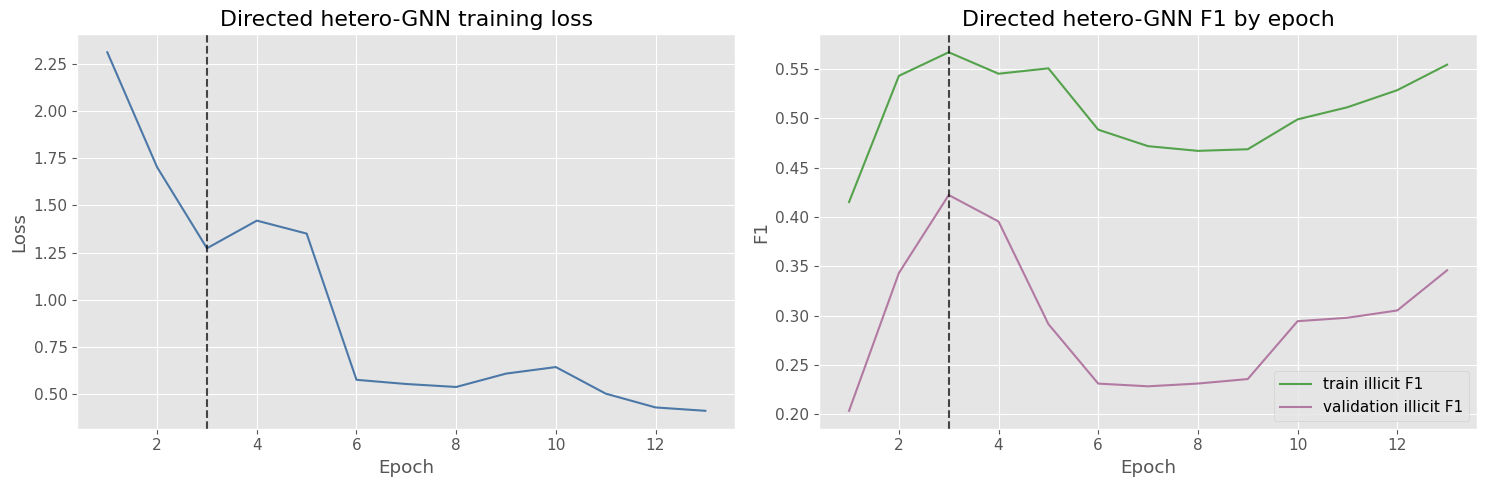

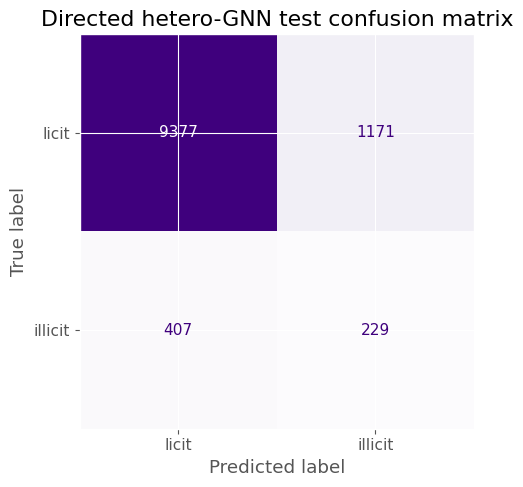

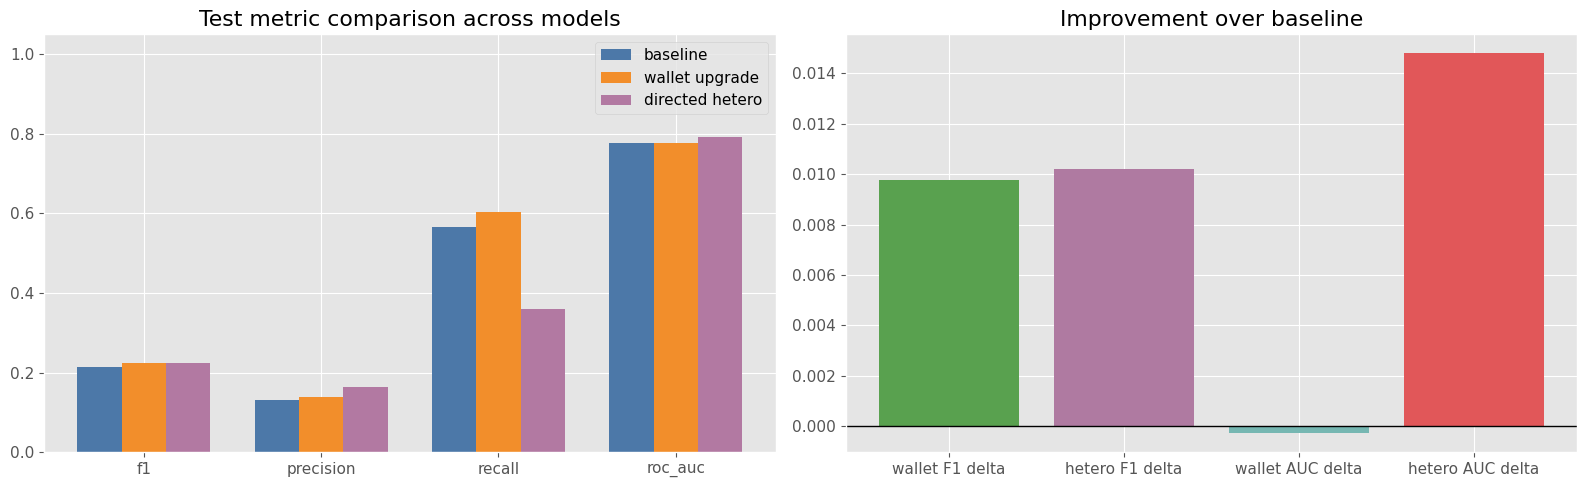

In [69]:
print(f'Directed hetero best epoch: {hetero_best_epoch}')
print(f'Directed hetero model saved to: {hetero_model_path}')
print('\nDirected hetero test classification report')
print(classification_report(hetero_test_labels, hetero_test_preds, target_names=['licit', 'illicit'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(hetero_history_df['epoch'], hetero_history_df['loss'], color='#4c78a8')
axes[0].axvline(hetero_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Directed hetero-GNN training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(hetero_history_df['epoch'], hetero_history_df['train_f1'], label='train illicit F1', color='#54a24b')
axes[1].plot(hetero_history_df['epoch'], hetero_history_df['val_f1'], label='validation illicit F1', color='#b279a2')
axes[1].axvline(hetero_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Directed hetero-GNN F1 by epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_directed_elliptic_pp_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(hetero_test_labels, hetero_test_preds), display_labels=['licit', 'illicit']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Directed hetero-GNN test confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_directed_elliptic_pp_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

metric_names = ['f1', 'precision', 'recall', 'roc_auc']
positions = np.arange(len(metric_names))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(positions - width, [test_metrics[m] for m in metric_names], width=width, label='baseline', color='#4c78a8')
axes[0].bar(positions, [upgraded_test_metrics[m] for m in metric_names], width=width, label='wallet upgrade', color='#f28e2b')
axes[0].bar(positions + width, [hetero_test_metrics[m] for m in metric_names], width=width, label='directed hetero', color='#b279a2')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Test metric comparison across models')
axes[0].legend()

axes[1].bar(
    ['wallet F1 delta', 'hetero F1 delta', 'wallet AUC delta', 'hetero AUC delta'],
    [
        model_comparison_df.loc[1, 'delta_f1_vs_baseline'],
        model_comparison_df.loc[2, 'delta_f1_vs_baseline'],
        model_comparison_df.loc[1, 'delta_auc_vs_baseline'],
        model_comparison_df.loc[2, 'delta_auc_vs_baseline'],
    ],
    color=['#59a14f', '#af7aa1', '#76b7b2', '#e15759'],
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Improvement over baseline')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_directed_elliptic_pp_vs_baselines.png', dpi=180, bbox_inches='tight')
plt.show()


## 11. Use `wallets_classes.csv` safely for training

This section adds the two label-usage strategies we discussed:

1. **Option 1: multi-task training**
   - predict transaction fraud labels on transaction nodes
   - predict wallet labels on address nodes at the same time

2. **Option 2: address pretraining then transaction fine-tuning**
   - first train the directed hetero encoder on wallet labels only
   - then initialize a transaction classifier from that encoder and fine-tune for fraud detection

Wallet labels are used only as **supervision targets**, never as raw input features.


In [70]:
import copy

wallet_class_labels = wallet_classes_raw.copy()
wallet_class_labels['class'] = wallet_class_labels['class'].astype(str)
wallet_class_labels['address_label'] = wallet_class_labels['class'].map(LABEL_MAP).fillna(-1).astype(np.int64)

address_step_candidates = pd.concat([
    wallet_features_for_nodes[['address', 'time_step']],
    tx_addr_edges_raw.rename(columns={'output_address': 'address'}).merge(
        transactions[['txId', 'time_step']], on='txId', how='inner'
    )[['address', 'time_step']],
    addr_tx_edges_raw.merge(
        transactions[['txId', 'time_step']], on='txId', how='inner'
    )[['address', 'time_step']],
], ignore_index=True).dropna()

address_first_seen = (
    address_step_candidates
    .groupby('address', as_index=False)['time_step']
    .min()
    .rename(columns={'time_step': 'first_seen_step'})
)

address_supervision = (
    address_frame[['address']]
    .merge(wallet_class_labels[['address', 'address_label']], on='address', how='left')
    .merge(address_first_seen, on='address', how='left')
)
address_supervision['address_label'] = address_supervision['address_label'].fillna(-1).astype(np.int64)

address_known_mask_np = address_supervision['address_label'].isin([0, 1]).to_numpy()
address_train_mask_np = (address_supervision['first_seen_step'].isin(TRAIN_STEPS) & address_supervision['address_label'].isin([0, 1])).to_numpy()
address_val_mask_np = (address_supervision['first_seen_step'].isin(VAL_STEPS) & address_supervision['address_label'].isin([0, 1])).to_numpy()
address_test_mask_np = (address_supervision['first_seen_step'].isin(TEST_STEPS) & address_supervision['address_label'].isin([0, 1])).to_numpy()

hetero_data_supervised = copy.deepcopy(hetero_data)
hetero_data_supervised['address'].y = torch.tensor(address_supervision['address_label'].to_numpy(dtype=np.int64), dtype=torch.long)
hetero_data_supervised['address'].train_mask = torch.tensor(address_train_mask_np, dtype=torch.bool)
hetero_data_supervised['address'].val_mask = torch.tensor(address_val_mask_np, dtype=torch.bool)
hetero_data_supervised['address'].test_mask = torch.tensor(address_test_mask_np, dtype=torch.bool)
hetero_data_supervised['address'].known_mask = torch.tensor(address_known_mask_np, dtype=torch.bool)

print(f'Labeled address nodes: {int(address_known_mask_np.sum()):,}')
print(f'Address train labels: {int(address_train_mask_np.sum()):,}')
print(f'Address val labels:   {int(address_val_mask_np.sum()):,}')
print(f'Address test labels:  {int(address_test_mask_np.sum()):,}')

pd.DataFrame({
    'node_type': ['transaction', 'address'],
    'train_labels': [int(hetero_data_supervised['transaction'].train_mask.sum()), int(hetero_data_supervised['address'].train_mask.sum())],
    'val_labels': [int(hetero_data_supervised['transaction'].val_mask.sum()), int(hetero_data_supervised['address'].val_mask.sum())],
    'test_labels': [int(hetero_data_supervised['transaction'].test_mask.sum()), int(hetero_data_supervised['address'].test_mask.sum())],
})


Labeled address nodes: 265,354
Address train labels: 172,903
Address val labels:   24,217
Address test labels:  68,234


,node_type,train_labels,val_labels,test_labels
0,transaction,29894,5486,11184
1,address,172903,24217,68234


## 12. Option 1: multi-task directed hetero-GNN

This model shares one directed hetero encoder across both tasks:
- transaction-node illicit-vs-licit classification
- address-node wallet illicit-vs-licit classification

The training objective is:
`transaction_loss + 0.3 * address_loss`


In [71]:
class MultiTaskDirectedHeteroGNN(nn.Module):
    def __init__(self, hidden_channels=128, dropout=0.35):
        super().__init__()
        self.dropout = dropout
        self.conv1 = HeteroConv(
            {
                ('transaction', 'tx_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('transaction', 'tx_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
            },
            aggr='sum',
        )
        self.conv2 = HeteroConv(
            {
                ('transaction', 'tx_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('transaction', 'tx_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_tx', 'transaction'): SAGEConv((-1, -1), hidden_channels),
                ('address', 'addr_to_addr', 'address'): SAGEConv((-1, -1), hidden_channels),
            },
            aggr='sum',
        )
        self.tx_head = nn.Linear(hidden_channels, 2)
        self.addr_head = nn.Linear(hidden_channels, 2)

    def encode(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(value) for key, value in x_dict.items()}
        x_dict = {key: F.dropout(value, p=self.dropout, training=self.training) for key, value in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: F.relu(value) for key, value in x_dict.items()}
        x_dict = {key: F.dropout(value, p=self.dropout, training=self.training) for key, value in x_dict.items()}
        return x_dict

    def forward(self, x_dict, edge_index_dict):
        encoded = self.encode(x_dict, edge_index_dict)
        return {
            'transaction': self.tx_head(encoded['transaction']),
            'address': self.addr_head(encoded['address']),
        }


def evaluate_multitask_node(logits, labels, mask):
    probabilities = torch.softmax(logits[mask], dim=1)[:, 1].cpu().numpy()
    predictions = logits[mask].argmax(dim=1).cpu().numpy()
    labels_np = labels[mask].cpu().numpy()
    metrics = {
        'f1': f1_score(labels_np, predictions, zero_division=0),
        'precision': precision_score(labels_np, predictions, zero_division=0),
        'recall': recall_score(labels_np, predictions, zero_division=0),
        'roc_auc': roc_auc_score(labels_np, probabilities) if len(np.unique(labels_np)) > 1 else np.nan,
    }
    return metrics, labels_np, predictions, probabilities


def train_multitask_directed_hetero(batch, model_path, address_loss_weight=0.3, hidden_channels=128, dropout=0.35, lr=1e-3, weight_decay=5e-4, epochs=60, patience=10):
    model_local = MultiTaskDirectedHeteroGNN(hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)
    batch = batch.to(DEVICE)
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr, weight_decay=weight_decay)

    tx_targets = batch['transaction'].y[batch['transaction'].train_mask]
    tx_class_counts = torch.bincount(tx_targets, minlength=2)
    tx_class_weights = (tx_class_counts.sum() / (2.0 * tx_class_counts.clamp_min(1))).to(torch.float32)
    tx_criterion = nn.CrossEntropyLoss(weight=tx_class_weights.to(DEVICE))

    addr_targets = batch['address'].y[batch['address'].train_mask]
    addr_class_counts = torch.bincount(addr_targets, minlength=2)
    addr_class_weights = (addr_class_counts.sum() / (2.0 * addr_class_counts.clamp_min(1))).to(torch.float32)
    addr_criterion = nn.CrossEntropyLoss(weight=addr_class_weights.to(DEVICE))

    history_local = []
    best_epoch_local = -1
    best_val_f1_local = -1.0
    best_state_local = None
    patience_counter_local = 0

    for epoch in range(1, epochs + 1):
        model_local.train()
        optimizer_local.zero_grad()
        out = model_local(batch.x_dict, batch.edge_index_dict)
        tx_loss = tx_criterion(
            out['transaction'][batch['transaction'].train_mask],
            batch['transaction'].y[batch['transaction'].train_mask],
        )
        addr_loss = addr_criterion(
            out['address'][batch['address'].train_mask],
            batch['address'].y[batch['address'].train_mask],
        )
        loss = tx_loss + address_loss_weight * addr_loss
        loss.backward()
        optimizer_local.step()

        model_local.eval()
        with torch.no_grad():
            eval_out = model_local(batch.x_dict, batch.edge_index_dict)
        tx_train_metrics, _, _, _ = evaluate_multitask_node(eval_out['transaction'], batch['transaction'].y, batch['transaction'].train_mask)
        tx_val_metrics, _, _, _ = evaluate_multitask_node(eval_out['transaction'], batch['transaction'].y, batch['transaction'].val_mask)
        addr_val_metrics, _, _, _ = evaluate_multitask_node(eval_out['address'], batch['address'].y, batch['address'].val_mask)

        history_local.append({
            'epoch': epoch,
            'loss': float(loss.item()),
            'tx_loss': float(tx_loss.item()),
            'addr_loss': float(addr_loss.item()),
            'train_tx_f1': tx_train_metrics['f1'],
            'val_tx_f1': tx_val_metrics['f1'],
            'val_addr_f1': addr_val_metrics['f1'],
            'val_tx_auc': tx_val_metrics['roc_auc'],
            'val_addr_auc': addr_val_metrics['roc_auc'],
        })

        if tx_val_metrics['f1'] > best_val_f1_local:
            best_val_f1_local = tx_val_metrics['f1']
            best_epoch_local = epoch
            best_state_local = {key: value.detach().cpu().clone() for key, value in model_local.state_dict().items()}
            torch.save(best_state_local, model_path)
            patience_counter_local = 0
        else:
            patience_counter_local += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | loss={loss.item():.4f} | "
                f"val_tx_f1={tx_val_metrics['f1']:.4f} | val_addr_f1={addr_val_metrics['f1']:.4f} | "
                f"val_tx_auc={tx_val_metrics['roc_auc']:.4f}"
            )

        if patience_counter_local >= patience:
            print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch_local})')
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    model_local.eval()
    with torch.no_grad():
        final_out = model_local(batch.x_dict, batch.edge_index_dict)

    tx_val_metrics, tx_val_labels, tx_val_preds, tx_val_probs = evaluate_multitask_node(final_out['transaction'], batch['transaction'].y, batch['transaction'].val_mask)
    tx_test_metrics, tx_test_labels, tx_test_preds, tx_test_probs = evaluate_multitask_node(final_out['transaction'], batch['transaction'].y, batch['transaction'].test_mask)
    addr_val_metrics, addr_val_labels, addr_val_preds, addr_val_probs = evaluate_multitask_node(final_out['address'], batch['address'].y, batch['address'].val_mask)
    addr_test_metrics, addr_test_labels, addr_test_preds, addr_test_probs = evaluate_multitask_node(final_out['address'], batch['address'].y, batch['address'].test_mask)

    return {
        'model': model_local,
        'history': pd.DataFrame(history_local),
        'best_epoch': best_epoch_local,
        'model_path': model_path,
        'tx_val_metrics': tx_val_metrics,
        'tx_val_labels': tx_val_labels,
        'tx_val_preds': tx_val_preds,
        'tx_val_probs': tx_val_probs,
        'tx_test_metrics': tx_test_metrics,
        'tx_test_labels': tx_test_labels,
        'tx_test_preds': tx_test_preds,
        'tx_test_probs': tx_test_probs,
        'addr_val_metrics': addr_val_metrics,
        'addr_val_labels': addr_val_labels,
        'addr_val_preds': addr_val_preds,
        'addr_val_probs': addr_val_probs,
        'addr_test_metrics': addr_test_metrics,
        'addr_test_labels': addr_test_labels,
        'addr_test_preds': addr_test_preds,
        'addr_test_probs': addr_test_probs,
    }

multitask_result = train_multitask_directed_hetero(
    hetero_data_supervised,
    MODEL_DIR / 'hetero_multitask_elliptic_pp_best.pt',
    address_loss_weight=0.3,
)
multitask_result['history'].tail()


Epoch 001 | loss=1.7261 | val_tx_f1=0.1689 | val_addr_f1=0.1214 | val_tx_auc=0.7634
Epoch 005 | loss=0.8357 | val_tx_f1=0.2092 | val_addr_f1=0.1621 | val_tx_auc=0.6132
Epoch 010 | loss=0.9940 | val_tx_f1=0.3617 | val_addr_f1=0.1618 | val_tx_auc=0.8978
Epoch 015 | loss=0.4828 | val_tx_f1=0.3009 | val_addr_f1=0.1831 | val_tx_auc=0.8059
Epoch 020 | loss=0.4844 | val_tx_f1=0.3354 | val_addr_f1=0.2986 | val_tx_auc=0.8295
Epoch 025 | loss=0.4134 | val_tx_f1=0.4212 | val_addr_f1=0.2993 | val_tx_auc=0.9136
Epoch 030 | loss=0.3402 | val_tx_f1=0.4125 | val_addr_f1=0.2906 | val_tx_auc=0.8851
Early stopping at epoch 33 (best epoch: 23)


,epoch,loss,tx_loss,addr_loss,train_tx_f1,val_tx_f1,val_addr_f1,val_tx_auc,val_addr_auc
28,29,0.336331,0.221218,0.383713,0.699379,0.418656,0.284683,0.889434,0.837188
29,30,0.340228,0.225613,0.382053,0.710995,0.412473,0.290617,0.885120,0.840208
30,31,0.353043,0.240712,0.374435,0.723186,0.419588,0.295733,0.887181,0.854744
31,32,0.328651,0.217967,0.368944,0.730091,0.433583,0.316792,0.891800,0.865309
32,33,0.339501,0.231915,0.358619,0.733844,0.458283,0.320911,0.897532,0.866812


Multi-task best epoch: 23
Multi-task model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/hetero_multitask_elliptic_pp_best.pt

Multi-task transaction test classification report
              precision    recall  f1-score   support

       licit       0.98      0.83      0.90     10548
     illicit       0.19      0.66      0.29       636

    accuracy                           0.82     11184
   macro avg       0.58      0.74      0.59     11184
weighted avg       0.93      0.82      0.86     11184

Address test metrics: {'f1': 0.14541862188194615, 'precision': 0.0860164787004032, 'recall': 0.46998722860791825, 'roc_auc': 0.7598757469024048}


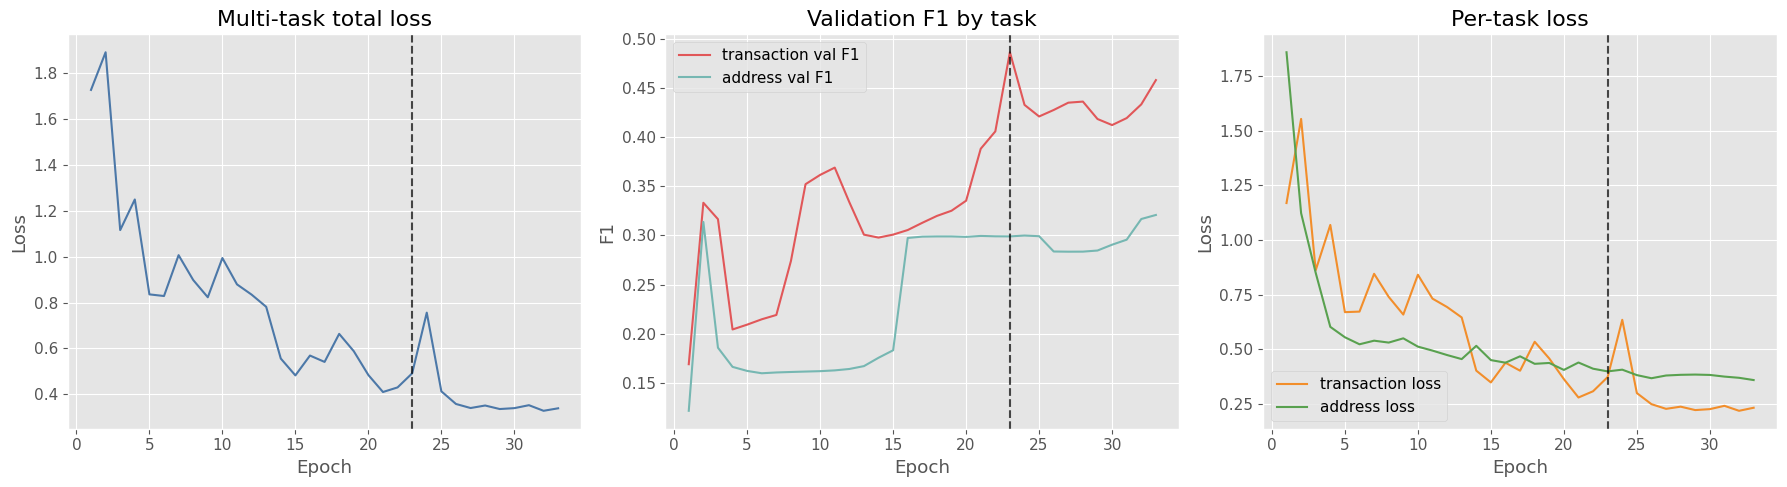

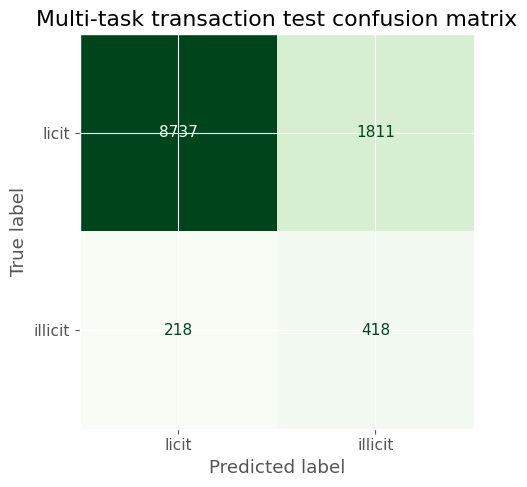

In [72]:
multitask_history_df = multitask_result['history']
multitask_best_epoch = multitask_result['best_epoch']
multitask_model_path = multitask_result['model_path']
multitask_tx_test_metrics = multitask_result['tx_test_metrics']
multitask_tx_test_labels = multitask_result['tx_test_labels']
multitask_tx_test_preds = multitask_result['tx_test_preds']
multitask_addr_test_metrics = multitask_result['addr_test_metrics']

print(f'Multi-task best epoch: {multitask_best_epoch}')
print(f'Multi-task model saved to: {multitask_model_path}')
print('\nMulti-task transaction test classification report')
print(classification_report(multitask_tx_test_labels, multitask_tx_test_preds, target_names=['licit', 'illicit'], zero_division=0))
print('Address test metrics:', multitask_addr_test_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(multitask_history_df['epoch'], multitask_history_df['loss'], color='#4c78a8')
axes[0].axvline(multitask_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Multi-task total loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(multitask_history_df['epoch'], multitask_history_df['val_tx_f1'], label='transaction val F1', color='#e15759')
axes[1].plot(multitask_history_df['epoch'], multitask_history_df['val_addr_f1'], label='address val F1', color='#76b7b2')
axes[1].axvline(multitask_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Validation F1 by task')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

axes[2].plot(multitask_history_df['epoch'], multitask_history_df['tx_loss'], label='transaction loss', color='#f28e2b')
axes[2].plot(multitask_history_df['epoch'], multitask_history_df['addr_loss'], label='address loss', color='#59a14f')
axes[2].axvline(multitask_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[2].set_title('Per-task loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_multitask_elliptic_pp_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(multitask_tx_test_labels, multitask_tx_test_preds),
    display_labels=['licit', 'illicit'],
).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Multi-task transaction test confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_multitask_elliptic_pp_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()


## 13. Option 2: address pretraining then transaction fine-tuning

This strategy first trains the directed hetero encoder only on address labels from `wallets_classes.csv`. After pretraining, the encoder weights initialize a transaction-fraud model, which is then fine-tuned on the transaction task.


In [73]:
def pretrain_address_encoder(batch, model_path, hidden_channels=128, dropout=0.35, lr=1e-3, weight_decay=5e-4, epochs=60, patience=10):
    model_local = MultiTaskDirectedHeteroGNN(hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)
    batch = batch.to(DEVICE)
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr, weight_decay=weight_decay)

    addr_targets = batch['address'].y[batch['address'].train_mask]
    addr_class_counts = torch.bincount(addr_targets, minlength=2)
    addr_class_weights = (addr_class_counts.sum() / (2.0 * addr_class_counts.clamp_min(1))).to(torch.float32)
    addr_criterion = nn.CrossEntropyLoss(weight=addr_class_weights.to(DEVICE))

    history_local = []
    best_epoch_local = -1
    best_val_f1_local = -1.0
    best_state_local = None
    patience_counter_local = 0

    for epoch in range(1, epochs + 1):
        model_local.train()
        optimizer_local.zero_grad()
        out = model_local(batch.x_dict, batch.edge_index_dict)
        addr_loss = addr_criterion(
            out['address'][batch['address'].train_mask],
            batch['address'].y[batch['address'].train_mask],
        )
        addr_loss.backward()
        optimizer_local.step()

        model_local.eval()
        with torch.no_grad():
            eval_out = model_local(batch.x_dict, batch.edge_index_dict)
        addr_train_metrics, _, _, _ = evaluate_multitask_node(eval_out['address'], batch['address'].y, batch['address'].train_mask)
        addr_val_metrics, _, _, _ = evaluate_multitask_node(eval_out['address'], batch['address'].y, batch['address'].val_mask)

        history_local.append({
            'epoch': epoch,
            'loss': float(addr_loss.item()),
            'train_addr_f1': addr_train_metrics['f1'],
            'val_addr_f1': addr_val_metrics['f1'],
            'val_addr_auc': addr_val_metrics['roc_auc'],
        })

        if addr_val_metrics['f1'] > best_val_f1_local:
            best_val_f1_local = addr_val_metrics['f1']
            best_epoch_local = epoch
            best_state_local = {key: value.detach().cpu().clone() for key, value in model_local.state_dict().items()}
            torch.save(best_state_local, model_path)
            patience_counter_local = 0
        else:
            patience_counter_local += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | loss={addr_loss.item():.4f} | "
                f"train_addr_f1={addr_train_metrics['f1']:.4f} | val_addr_f1={addr_val_metrics['f1']:.4f} | "
                f"val_addr_auc={addr_val_metrics['roc_auc']:.4f}"
            )

        if patience_counter_local >= patience:
            print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch_local})')
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    model_local.eval()
    with torch.no_grad():
        final_out = model_local(batch.x_dict, batch.edge_index_dict)
    addr_val_metrics, addr_val_labels, addr_val_preds, addr_val_probs = evaluate_multitask_node(final_out['address'], batch['address'].y, batch['address'].val_mask)
    addr_test_metrics, addr_test_labels, addr_test_preds, addr_test_probs = evaluate_multitask_node(final_out['address'], batch['address'].y, batch['address'].test_mask)

    return {
        'model': model_local,
        'history': pd.DataFrame(history_local),
        'best_epoch': best_epoch_local,
        'model_path': model_path,
        'addr_val_metrics': addr_val_metrics,
        'addr_val_labels': addr_val_labels,
        'addr_val_preds': addr_val_preds,
        'addr_val_probs': addr_val_probs,
        'addr_test_metrics': addr_test_metrics,
        'addr_test_labels': addr_test_labels,
        'addr_test_preds': addr_test_preds,
        'addr_test_probs': addr_test_probs,
    }


def finetune_from_address_pretraining(batch, pretrained_model, model_path, hidden_channels=128, dropout=0.35, lr=1e-3, weight_decay=5e-4, epochs=60, patience=10):
    model_local = DirectedHeteroFraudGNN(hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)
    batch = batch.to(DEVICE)

    # Materialize lazy layers before loading shared encoder weights.
    with torch.no_grad():
        _ = model_local(batch.x_dict, batch.edge_index_dict)

    pretrained_state = pretrained_model.state_dict()
    encoder_state = {key: value for key, value in pretrained_state.items() if key.startswith('conv')}
    model_local.load_state_dict(encoder_state, strict=False)

    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr, weight_decay=weight_decay)
    tx_targets = batch['transaction'].y[batch['transaction'].train_mask]
    tx_class_counts = torch.bincount(tx_targets, minlength=2)
    tx_class_weights = (tx_class_counts.sum() / (2.0 * tx_class_counts.clamp_min(1))).to(torch.float32)
    tx_criterion = nn.CrossEntropyLoss(weight=tx_class_weights.to(DEVICE))

    history_local = []
    best_epoch_local = -1
    best_val_f1_local = -1.0
    best_state_local = None
    patience_counter_local = 0

    for epoch in range(1, epochs + 1):
        model_local.train()
        optimizer_local.zero_grad()
        logits_local = model_local(batch.x_dict, batch.edge_index_dict)
        tx_loss = tx_criterion(
            logits_local[batch['transaction'].train_mask],
            batch['transaction'].y[batch['transaction'].train_mask],
        )
        tx_loss.backward()
        optimizer_local.step()

        train_metrics_local, _, _, _ = evaluate_directed_hetero(model_local, batch, batch['transaction'].train_mask)
        val_metrics_local, _, _, _ = evaluate_directed_hetero(model_local, batch, batch['transaction'].val_mask)
        history_local.append({
            'epoch': epoch,
            'loss': float(tx_loss.item()),
            'train_f1': train_metrics_local['f1'],
            'val_f1': val_metrics_local['f1'],
            'val_precision': val_metrics_local['precision'],
            'val_recall': val_metrics_local['recall'],
            'val_roc_auc': val_metrics_local['roc_auc'],
        })

        if val_metrics_local['f1'] > best_val_f1_local:
            best_val_f1_local = val_metrics_local['f1']
            best_epoch_local = epoch
            best_state_local = {key: value.detach().cpu().clone() for key, value in model_local.state_dict().items()}
            torch.save(best_state_local, model_path)
            patience_counter_local = 0
        else:
            patience_counter_local += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | loss={tx_loss.item():.4f} | "
                f"train_f1={train_metrics_local['f1']:.4f} | val_f1={val_metrics_local['f1']:.4f} | "
                f"val_auc={val_metrics_local['roc_auc']:.4f}"
            )

        if patience_counter_local >= patience:
            print(f'Early stopping at epoch {epoch} (best epoch: {best_epoch_local})')
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    val_metrics_local, val_labels_local, val_preds_local, val_probs_local = evaluate_directed_hetero(model_local, batch, batch['transaction'].val_mask)
    test_metrics_local, test_labels_local, test_preds_local, test_probs_local = evaluate_directed_hetero(model_local, batch, batch['transaction'].test_mask)
    return {
        'model': model_local,
        'history': pd.DataFrame(history_local),
        'best_epoch': best_epoch_local,
        'model_path': model_path,
        'val_metrics': val_metrics_local,
        'val_labels': val_labels_local,
        'val_preds': val_preds_local,
        'val_probs': val_probs_local,
        'test_metrics': test_metrics_local,
        'test_labels': test_labels_local,
        'test_preds': test_preds_local,
        'test_probs': test_probs_local,
    }

address_pretrain_result = pretrain_address_encoder(
    hetero_data_supervised,
    MODEL_DIR / 'hetero_address_pretrain_elliptic_pp_best.pt',
)
address_finetune_result = finetune_from_address_pretraining(
    hetero_data_supervised,
    address_pretrain_result['model'],
    MODEL_DIR / 'hetero_address_pretrain_finetune_elliptic_pp_best.pt',
)

address_pretrain_result['history'].tail(), address_finetune_result['history'].tail()


Epoch 001 | loss=3.7416 | train_addr_f1=0.0143 | val_addr_f1=0.1663 | val_addr_auc=0.5748
Epoch 005 | loss=0.6582 | train_addr_f1=0.3971 | val_addr_f1=0.3061 | val_addr_auc=0.7995
Epoch 010 | loss=0.5647 | train_addr_f1=0.2173 | val_addr_f1=0.2567 | val_addr_auc=0.7992
Early stopping at epoch 14 (best epoch: 4)
Epoch 001 | loss=2.3459 | train_f1=0.2295 | val_f1=0.3949 | val_auc=0.8407
Epoch 005 | loss=1.5057 | train_f1=0.4864 | val_f1=0.2693 | val_auc=0.7915
Epoch 010 | loss=0.6131 | train_f1=0.4710 | val_f1=0.2250 | val_auc=0.6657
Early stopping at epoch 11 (best epoch: 1)


(    epoch      loss  train_addr_f1  val_addr_f1  val_addr_auc
 9      10  0.564723       0.217326     0.256651      0.799241
 10     11  0.586658       0.222413     0.255814      0.801060
 11     12  0.538225       0.251192     0.257342      0.803851
 12     13  0.490177       0.314606     0.261944      0.806497
 13     14  0.477513       0.366728     0.264921      0.810785,
     epoch      loss  train_f1    val_f1  val_precision  val_recall  \
 6       7  0.954382  0.436214  0.213665       0.120179    0.961969   
 7       8  0.712340  0.440498  0.216849       0.122020    0.973154   
 8       9  0.785573  0.452348  0.220980       0.124642    0.973154   
 9      10  0.613076  0.471015  0.224961       0.127413    0.959732   
 10     11  0.557290  0.510414  0.282695       0.165827    0.957494   
 
     val_roc_auc  
 6      0.646976  
 7      0.650674  
 8      0.655362  
 9      0.665714  
 10     0.804994  )

Address pretrain best epoch: 4
Address pretrain model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/hetero_address_pretrain_elliptic_pp_best.pt
Address-only test metrics: {'f1': 0.185876326381266, 'precision': 0.12057343586822368, 'recall': 0.4054916985951469, 'roc_auc': 0.7065386449471001}
Fine-tuned model best epoch: 1
Fine-tuned model saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/models/hetero_address_pretrain_finetune_elliptic_pp_best.pt

Address-pretrained fine-tuned transaction test classification report
              precision    recall  f1-score   support

       licit       0.97      0.81      0.88     10548
     illicit       0.15      0.57      0.24       636

    accuracy                           0.79     11184
   macro avg       0.56      0.69      0.56     11184
weighted avg       0.92      0.79      0.84     11184



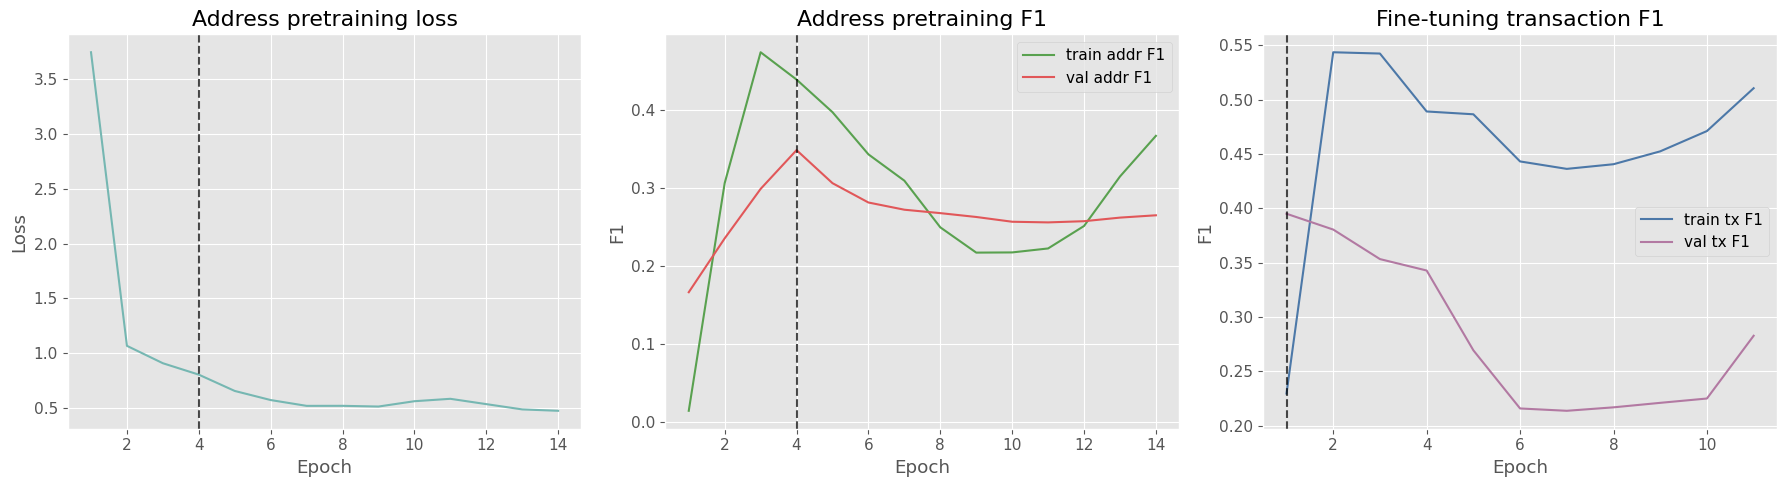

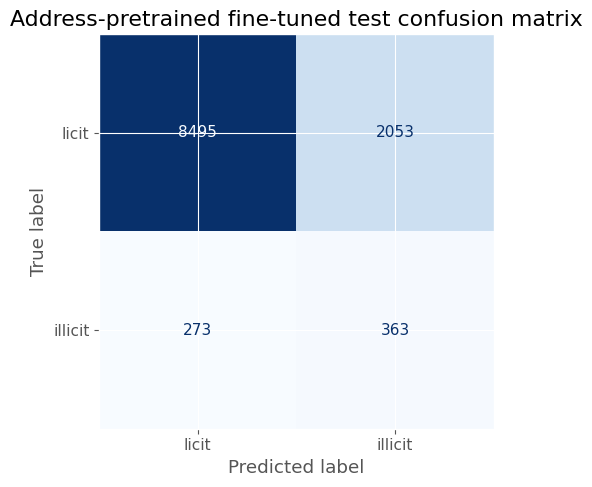

In [74]:
address_pretrain_history_df = address_pretrain_result['history']
address_pretrain_best_epoch = address_pretrain_result['best_epoch']
address_pretrain_model_path = address_pretrain_result['model_path']
address_pretrain_addr_test_metrics = address_pretrain_result['addr_test_metrics']

address_finetune_history_df = address_finetune_result['history']
address_finetune_best_epoch = address_finetune_result['best_epoch']
address_finetune_model_path = address_finetune_result['model_path']
address_finetune_test_metrics = address_finetune_result['test_metrics']
address_finetune_test_labels = address_finetune_result['test_labels']
address_finetune_test_preds = address_finetune_result['test_preds']

print(f'Address pretrain best epoch: {address_pretrain_best_epoch}')
print(f'Address pretrain model saved to: {address_pretrain_model_path}')
print('Address-only test metrics:', address_pretrain_addr_test_metrics)
print(f'Fine-tuned model best epoch: {address_finetune_best_epoch}')
print(f'Fine-tuned model saved to: {address_finetune_model_path}')
print('\nAddress-pretrained fine-tuned transaction test classification report')
print(classification_report(address_finetune_test_labels, address_finetune_test_preds, target_names=['licit', 'illicit'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(address_pretrain_history_df['epoch'], address_pretrain_history_df['loss'], color='#76b7b2')
axes[0].axvline(address_pretrain_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Address pretraining loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(address_pretrain_history_df['epoch'], address_pretrain_history_df['train_addr_f1'], label='train addr F1', color='#59a14f')
axes[1].plot(address_pretrain_history_df['epoch'], address_pretrain_history_df['val_addr_f1'], label='val addr F1', color='#e15759')
axes[1].axvline(address_pretrain_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Address pretraining F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

axes[2].plot(address_finetune_history_df['epoch'], address_finetune_history_df['train_f1'], label='train tx F1', color='#4c78a8')
axes[2].plot(address_finetune_history_df['epoch'], address_finetune_history_df['val_f1'], label='val tx F1', color='#b279a2')
axes[2].axvline(address_finetune_best_epoch, color='black', linestyle='--', alpha=0.7)
axes[2].set_title('Fine-tuning transaction F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_address_pretrain_finetune_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(address_finetune_test_labels, address_finetune_test_preds),
    display_labels=['licit', 'illicit'],
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Address-pretrained fine-tuned test confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hetero_address_pretrain_finetune_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()


## 14. Final comparison across every model

This final table and figure compare all transaction-fraud models built in the notebook:
- baseline transaction GCN
- wallet-feature upgraded GCN
- directed hetero-GNN
- multi-task directed hetero-GNN
- address-pretrained then fine-tuned directed hetero-GNN


In [75]:
all_model_results_df = pd.DataFrame([
    {'model': 'baseline_gcn', **test_metrics},
    {'model': 'wallet_upgrade_gcn', **upgraded_test_metrics},
    {'model': 'directed_hetero_gnn', **hetero_test_metrics},
    {'model': 'multitask_directed_hetero_gnn', **multitask_tx_test_metrics},
    {'model': 'address_pretrain_finetune_hetero_gnn', **address_finetune_test_metrics},
])
all_model_results_df['delta_f1_vs_baseline'] = all_model_results_df['f1'] - all_model_results_df.loc[0, 'f1']
all_model_results_df['delta_auc_vs_baseline'] = all_model_results_df['roc_auc'] - all_model_results_df.loc[0, 'roc_auc']
all_model_results_df = all_model_results_df.sort_values('f1', ascending=False).reset_index(drop=True)
all_model_results_df


,model,f1,precision,recall,roc_auc,delta_f1_vs_baseline,delta_auc_vs_baseline
0,multitask_directed_hetero_gnn,0.291798,0.187528,0.657233,0.855995,0.077064,0.078826
1,address_pretrain_finetune_hetero_gnn,0.237877,0.150248,0.570755,0.788488,0.023144,0.011319
2,directed_hetero_gnn,0.224951,0.163571,0.360063,0.791966,0.010218,0.014797
3,wallet_upgrade_gcn,0.224496,0.137882,0.603774,0.776892,0.009763,-0.000276
4,baseline_gcn,0.214733,0.132499,0.566038,0.777169,0.000000,0.000000


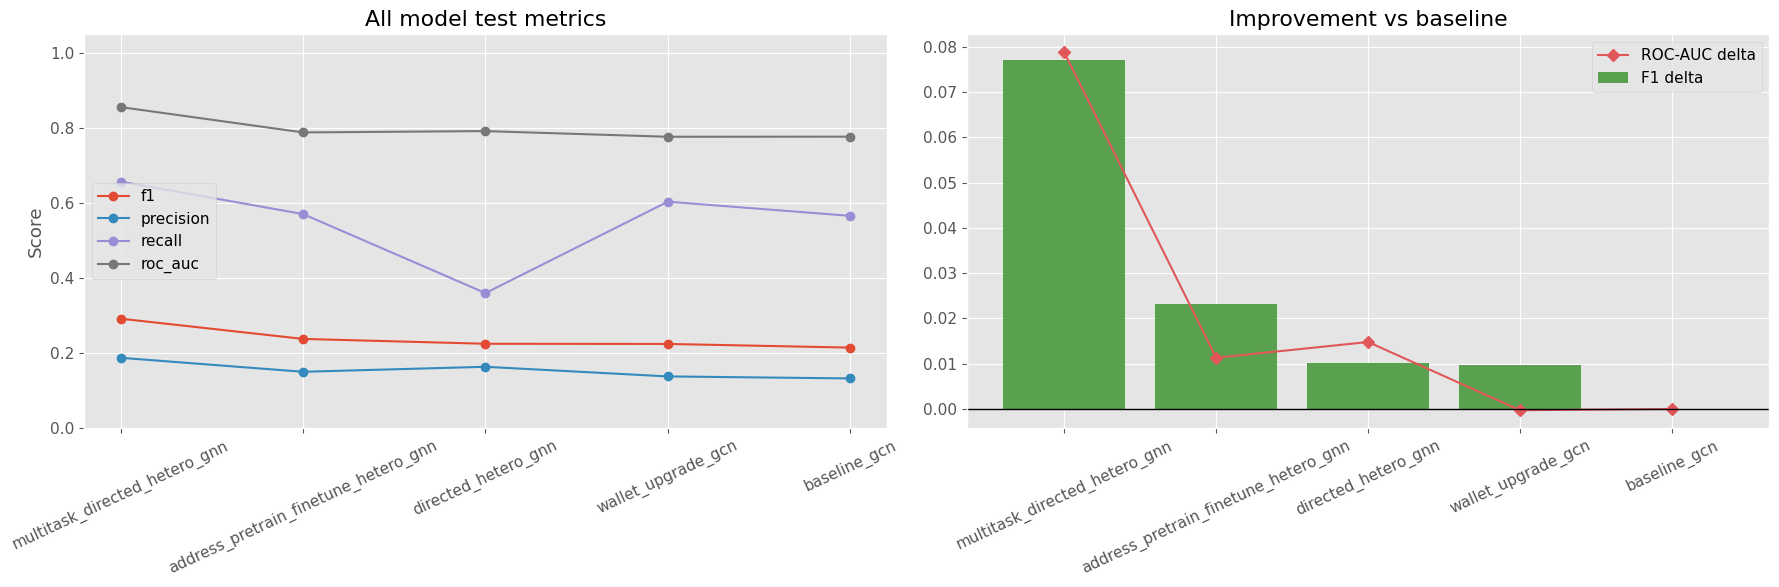

Best model by illicit F1:
model                    multitask_directed_hetero_gnn
f1                                            0.291798
precision                                     0.187528
recall                                        0.657233
roc_auc                                       0.855995
delta_f1_vs_baseline                          0.077064
delta_auc_vs_baseline                         0.078826
Name: 0, dtype: object


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
metric_names = ['f1', 'precision', 'recall', 'roc_auc']
positions = np.arange(len(all_model_results_df))

for metric_name in metric_names:
    axes[0].plot(all_model_results_df['model'], all_model_results_df[metric_name], marker='o', label=metric_name)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('All model test metrics')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()

axes[1].bar(all_model_results_df['model'], all_model_results_df['delta_f1_vs_baseline'], color='#59a14f', label='F1 delta')
axes[1].plot(all_model_results_df['model'], all_model_results_df['delta_auc_vs_baseline'], marker='D', color='#e15759', label='ROC-AUC delta')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Improvement vs baseline')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'elliptic_pp_all_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

print('Best model by illicit F1:')
print(all_model_results_df.iloc[0])
